<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS7 - Filtrado digital lineal de ECG*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

## <u> Procesamiento digital del *ECG* </u> 

El electrocardiograma (*ECG*) es una señal biomédica que refleja la actividad electrica del corazón durante cada ciclo cardíaco. Su análisis permite identificar patologías, alteraciones del ritmo cardíaco y variaciones en la conducción eléctrica. Los principales componentes de un latido son:

- **Onda P**: representa la despolarización auricular (las cavidades superiores del corazón se activan eléctricamente). Es de baja amplitud ($ \approx 0.1 - 0.2 mV $) y relativamente lenta (duracion $\approx 80 ms $).
- **Complejo QRS**: corresponde a la despolarización ventricular (activación eléctrica de los ventrículos, las cavidades encargadas de bombear sangre al cuerpo). Es el componente de mayor energía y rapidez en el ECG (duración $\approx 80 - 120 ms$). Su pendiente pronunciada requiere preservar componentes de frecuencia relativamente altas.
- **Onda T**: asociada a la repolarización ventricular (luego de activarse, las células vuelven a su voltaje "de reposo"). Es más ancha que la onda P y su contenido espectral es de menor frecuencia que el QRS.

Durante mediciones reales, especialmente en pruebas de esfuerzo, la señal suele contaminarse con diversas fuentes de ruido que modifican su morfología. Por este motivo, el **filtrado digital** constituye una herramienta fundamental para recuperar la informacion relevante de la señal, preservando la forma típica de los latidos y su nivel isoeléctrico (potencial de referencia donde el voltaje es idealmente cero).

El procesamiento digital se basa en la representación muestreada de la señal y en la aplicación de transformaciones en el dominio temporal o frecuencial para atenuar interferencias sin alterar la forma característica del latido.

## <u> Contenido espectral del *ECG* y consideraciones prácticas </u>

El *ECG* es una señal con espectro conocido, cuyo contenido útil se encuentra aproximadamente en: 

- $0.5 - 40 Hz$: energía principal de ondas P, QRS y T.

- $50 Hz$: interferencia de red electrica.

- $> 40 - 45 Hz$: ruido muscular (*EMG*) y artefactos de movimiento. 
Las principales componentes del *ECG* tienen ontenido espectral relativamente actado: 

Conservar la morfología del QRS y las ondas P y T requiere diseñar filtros que supriman las interferencias (baja y alta frecuencia, y ruido de línea) sin distorcionar las características temporales y espectrales de la señal útil. 

## <u> Fuentes principales de contaminación en el *ECG* </u>

En registros clínicos reales aparecen tres interferencias dominantes: 

1. **Derivada de linea base (*baseline wander*)**: oscilaciones lentas ($< 0.5 $) provocadas por la respiración, movimientos del paciente o cambios en la impedancia eléctrica de los electrodos. Desplaza el nivel isoeléctrico, dificultando medir amplitudes. 
2. **Ruido muscular (*EMG*)**: generado por la actividad de los músculos adyacentes, posee un espectro amplio y contribuye principalmente en alta frecuencia (banda ancha $ 40 - 200 Hz $). Durante esfuerzo físico su presencia es intensa y variable.
3. **Artefactos por movimiento de electrodos**: cambios abruptos en el contacto que introducen transitorios y contenido de alta frecuencia, pudiendo deformar el complejo QRS y saturar el registro.

Cada una de estas interferencias ocupa regiones espectrales distintas, lo que fundamenta el uso de filtros *pasa-banda* acotados o combinaciones de filtros *pasa-alto* y *pasa-bajo*, para preservar el rango de interés del *ECG*. 

## <u> Banda útil del *ECG* </u>

Para señales de superficie típicas se considera adecuada la banda: $ 0.5 Hz \leq frecuencia \leq 40 Hz $.

Esta banda conserva la energía principal de P, QRS y T, atenúa la deriva de línea de base (por debajo de $ 0.5 Hz $) y reduce el ruido muscular y artefactos de alta frecuencia. En pruebas de esfuerzo puede observarse contenido útil ligeramente superior (hasta $ 80 - 100 Hz $), pero la banda clásica $ 0.5 - 40 Hz $ suele ser la referencia para obtener trazos suaves y clínicamente interpretables. 

## <u> Concepto de *ripple* </u>

Al diseñar filtros, especialmente en el dominio frecuencial, aparece el consepto de **ripple**: 

- Es la variación no deseada de la ganancia dentro de una banda (de paso o se rechazo).
- En la banda de paso, el ripple implica que algunas frecuencias se amplifican o atenúan ligeramente.
- En la banda de rechazo, el ripple significa que la atenuación no es constante, sino que oscila alrededor del nivel deseado.

Hay filtros que permiten controlar y limitar el ripple para obtener transiciones más abruptas con orden mayor. 

## <u> Plantilla de diseño </u>

Para diseñar un filtro se establecen especificaciones expresadas mediante una **plantilla** (*mask*): 

- **Banda de paso**: frecuencias útiles de la señal.
- **Banda de rechazo**: frecuencias donde se exige una atenuación mínima para eliminar interferencias:
    - $< 0.5 Hz$ (deriva del nivel isoeléctrico).
    - $40 Hz$ (ruido *EMG*, artefactos).
    - $50 Hz$ (línea eléctrica).
- **Ripple admisible en banda**: los valores tipicos son $0.1 - 1 dB $ en banda de paso y $20 - 60 dB$ de atenuacion en banda de rechazo.
- **Frecuencias de transición**: separan las bandas de paso y las de rechazo. Cuanto mas estrechos sean estos bordes, mayor sera el orden del filtro. 
- **Atenuación en banda de paso**: es el máximo error permitido dentro de la banda donde el filtro debe dejar pasar la señal. 
- **Atenuación en banda de rechazo**: es la mínima atenuación requerida para suprimir interferencias.

La respuesta en frecuencia final debe ajustarse a estos valores para garantizar que la señal filtrada sea representativa y clínicamente útil. 

## <u> Tipos de filtros </u>

### *IIR* (Infinite Impulse Response)

Un **filtro IIR** (*respuesta infinita al impulso*) es un filtro digital que utiliza realimentación interna, lo que hace que su respuesta al impulso teóricamente dure para siempre (aunque en la práctica de atenúe). Gracias a esa realimentación, los *IIR* pueden lograr transiciones muy rápidas con orden mucho menor que un *FIR* equivalente. 

Su desventaja es que presentan fase no lineal, lo que puede deformar la señal. Esta distorsión puede corregirse usando técnicas de *python* como *filtfilt*. 

Conviene utilizarlos cuando se busca eficiencia computacional o cuando se requiere un filtro de orden bajo. 

#### Métodos de diseño *IIR*

1. **Butterworth**
    - Máxima planicidad en banda de paso.
    - Sin ripple.
    - Transición suave y orden mayor para especificaciones estrictas.
    - Ideal cuando lo más importante es evitar el ripple y suavizar el trazo.
2. **Chebyshev Tipo I**
    - Ripple en banda de paso, banda de rechazo libre de ripple.
    - Transición más abrupta que Butterworth para igual orden.
    - Útil cuando se tolera un poco de ripple para obtener filtros más eficientes.
3. **Chebyshev Tipo II**
    - Sin ripple en banda de paso.
    - Ripple en banda de rechazo.
    - Buena opción cuando la banda de paso debe ser muy limpia.
4. **Elíptico / Cauer**
    - Ripple en ambas bandas.
    - Transiciones más abruptas.
    - Es el más eficiente en términos de orden, pero puede introducir distorsión si las especificaciones son agresivas.

### *FIR* (Finite Impulse Response)

Un **filtro FIR** (*respuesta finita al impulso*) es un filtro digital cuya respuesta al impulso dura un número finito de muestras. No utiliza realimentación, por lo que siempre es estable. 

La característica más importante es que puede diseñarse con fase lineal, lo que significa que no altera la forma temporal de la señal. Por este motivo, los *FIR* son ideales cuando se necesita máxima fidelidad en la forma de onda, aunque a veces requieren órdenes más altos para lograr transiciones bruscas. 

Los filtros FIR con fase lineal pueden clasificarse según la longitud de la respuesta al impulso y la simetría de sus coeficientes. Existen cuatro tipos principales: 

- **Tipo I**: Tiene número impar de coeficientes, y su respuesta al impulso es simétrica.
- **Tipo II**: Tiene número par de coeficientes, y su respuesta al impulso es simétrica.
- **Tipo III**: Tiene número impar de coeficientes, y su respuesta al impulso es antisimétrica.
- **Tipo IV**: Tiene número par de coeficientes, y su respuesta al impulso es antisimétrica. 

#### Métodos de diseño *FIR*

1. **Ventanas (Hamming, Blackman, etc.)**
    - Se parte de la respuesta ideal (por ejemplo un *pasa-banda* rectangular en frecuencia).
    - Se multiplica por una ventana que suaviza los bordes.
    - Ventanas diferentes producen distintos compromisos entre ancho del lóbulo principal y atenuación lateral.
    - Es el método más simple, pero no optimiza el error en forma estricta.
2. **Mínimos cuadrados (*Least Squares*)**
    - Minimiza el error cuadrático promedio entre la respuesta deseada e ideal.
    - Produce filtros con buena aproximación global en banda de paso y de rechazo.
    - No controla de forma estricta los máximos errores (no es equiripple).
3. **Equiripple (*Parks - McClellan / Remez*)**
    - Minimiza el error máximo en cada banda.
    - El ripple es uniforme en cada banda.
    - Produce el filtro de orden mínimo que cumple la plantilla.
    - Ideal cuando se quiere precisión y eficiencia. 

# <u>**Desarrollo**</u>

En el presente trabajo se abordó el diseño e implementación de distintos filtros digitales con el objetivo de procesar una señal electrocardiográfica (*ECG*) real y mitigar las principales fuentes de ruido e interferencia presentes en ella. Para ello, se establecieron plantillas de diseño adecuadas a las características espectrales de la señal y se evaluó el desempeño de diferentes aproximaciones de filtrado *FIR* e *IIR*. 

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas, así como los criterios utilizados para evaluar el desempeño de los filtros obtenidos.  

## *Diseño de la plantilla* 

Como primer paso, se definieron especificaciones de diseño de los filtros a partir del ancho de banda estimado para la señal *ECG* en la Tarea Semanal 5. Considerando que la información de interés se encuentra principalmente entre $1Hz$ y $35Hz$, se adoptó una plantilla de *filtro pasa - banda* con frecuencias de paso $w_{p1}=1Hz$ y $w_{p2}=35Hz$. 

Para las bandas de rechazo se seleccionaron $w_{s1}=0.1Hz$ y $w_{s2}=45Hz$, con una ondulación máxima en banda de paso de $1dB$ y una atenuación mínima de $40dB$ en banda de rechazo. Estas especificaciones permiten atenuar tanto las componentes de muy baja frecuencia asociadas al movimiento de la línea de base como las componentes de alta frecuencia producidas por ruido muscular y movimiento de electrodos. 

A continuación, se definieron los parámetros de la plantilla y se generó una grilla de frecuencias adecuada para evaluar la respuesta en frecuencia de los filtros diseñados. 

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
from pytc2.sistemas_lineales import plot_plantilla

# Frecuencia 
fs = 1000 # Hz

# ww es para el WorN
ww = np.concatenate([np.logspace(start = -2, stop = 0.1, num = 500),
                np.linspace(start = 1.26, stop = 35, num = 200),
                np.logspace(start = 1.55, stop = 1.65, num = 300),
                np.linspace(start = 46, stop = fs//2, num = 50)])
ww = np.sort(ww)

# Plantilla de diseño del filtro 
wp1 = 1 # Hz
wp2 = 35 # Hz --> 30 es aprox el ancho de banda que nos dio en la TS5
ws1 = .1 # Hz 
ws2 = 45 # Hz
gpass = 1 # dB
gstop = 40 # dB 

wp = (wp1, wp2) # Comienzo y fin de la banda de paso
ws = (ws1, ws2) # Comienzo y fin de la banda de stop

## *Diseño de filtros IIR*

Una vez establecida la plantilla, se diseñaron distintos filtros IIR utilizando la función `iirdesign()` de *SciPy*. Se seleccionaron tres aproximaciones diferentes para comparar su comportamiento: 

- Butterworth, de máxima planicidad.
- Cauer o elíptico, equiripple tanto en banda de paso como en banda de rechazo.
- Chebyshev tipo II, equiripple en banda de rechazo.

Los filtros se implementaron en forma de secciones de segundo orden (*SOS*), ya que esta representación presenta una mejor estabilidad numérica que la implementación directa mediante coeficientes del numerador y denominador. 

In [82]:
# Funciones de aproximacion 
sos_f_butter = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'butter', output = 'sos', fs = fs) # Es de maxima planicidad en ambas bandas 
sos_f_cauer = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cauer', output = 'sos', fs = fs)
sos_f_cheby2 = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cheby2', output = 'sos', fs = fs)

# BUTTERWORTH
taps_butter = sos_f_butter.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_butter, resp_freq_butter = sig.freqz_sos(sos_f_butter, worN = ww, fs = fs)
phase_butter = np.unwrap(np.angle(resp_freq_butter))
gd_butter = -np.diff(phase_butter) / np.diff(ww)
gd_butter = np.append(gd_butter[0], gd_butter)

# CAUER O ELIPTICO 
taps_cauer = sos_f_cauer.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_cauer, resp_freq_cauer = sig.freqz_sos(sos_f_cauer, worN = ww, fs = fs)
phase_cauer = np.unwrap(np.angle(resp_freq_cauer))
gd_cauer = -np.diff(phase_cauer) / np.diff(ww)
gd_cauer = np.append(gd_cauer[0], gd_cauer)

# CHEBYSHEV TIPO 2
taps_cheby2 = sos_f_cheby2.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_cheby2, resp_freq_cheby2 = sig.freqz_sos(sos_f_cheby2, worN = ww, fs = fs)
phase_cheby2 = np.unwrap(np.angle(resp_freq_cheby2))
gd_cheby2 = -np.diff(phase_cheby2) / np.diff(ww)
gd_cheby2 = np.append(gd_cheby2[0], gd_cheby2)

Para cada aproximación se obtuvo la respuesta en magnitud, fase y retardo de grupo. La respuesta en magnitud permite verificar el cumplimiento de la plantilla de diseño, mientras que la fase y el retardo de grupo permiten evaluar las distorsiones temporales introducidas por el filtro. 

En particular, se buscó que el retardo de grupo fuera lo más constante posible dentro de la banda de paso y que la fase presentara un comportamiento aproximadamente lineal. Estas características indican que todas las componentes espectrales de interés sufren retardos similares, preservando la forma temporal de la señal *ECG*. 

### *Butterworth*

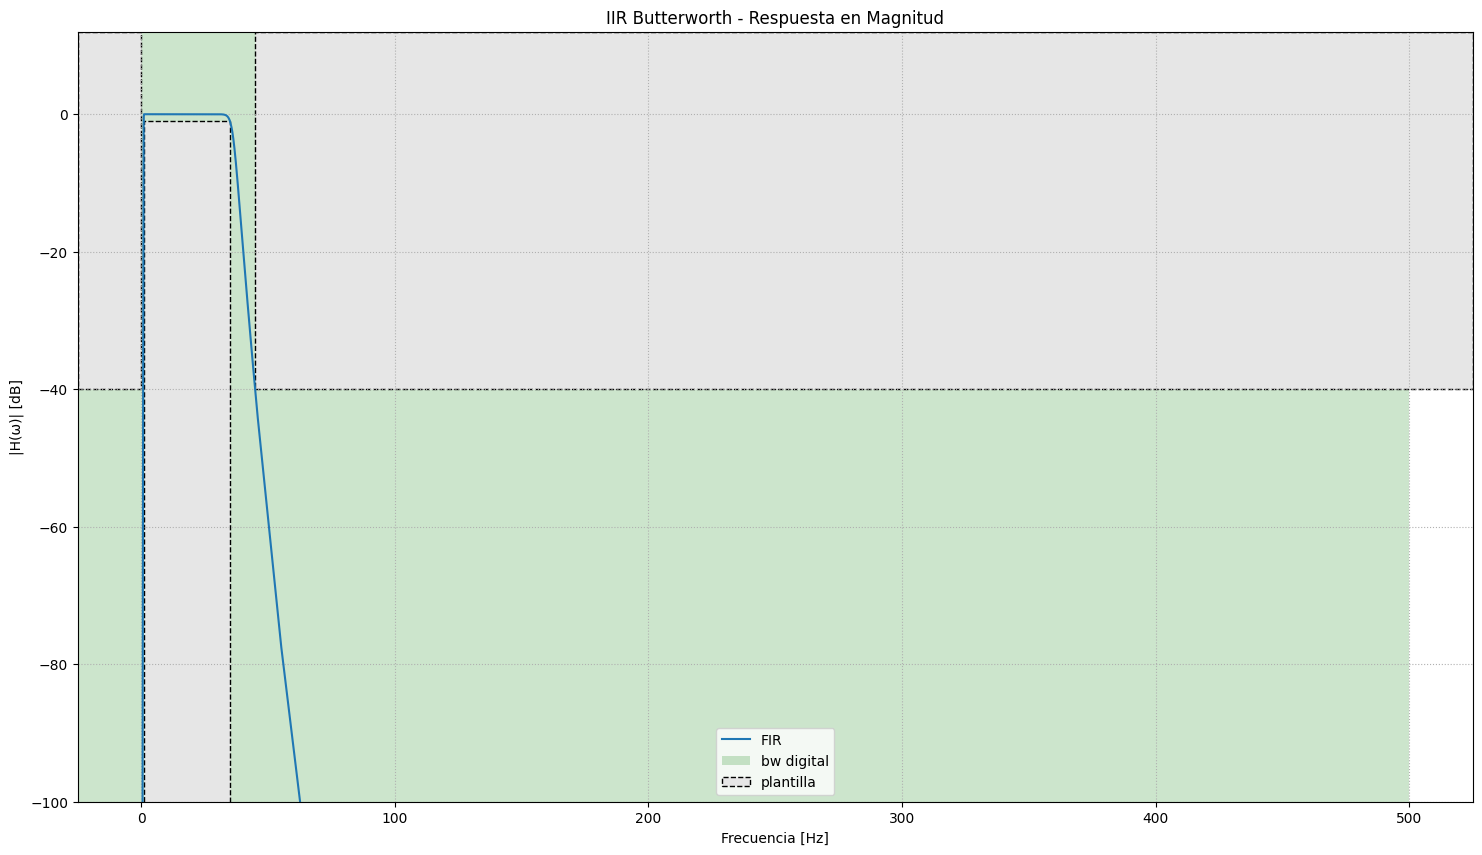

<Figure size 640x480 with 0 Axes>

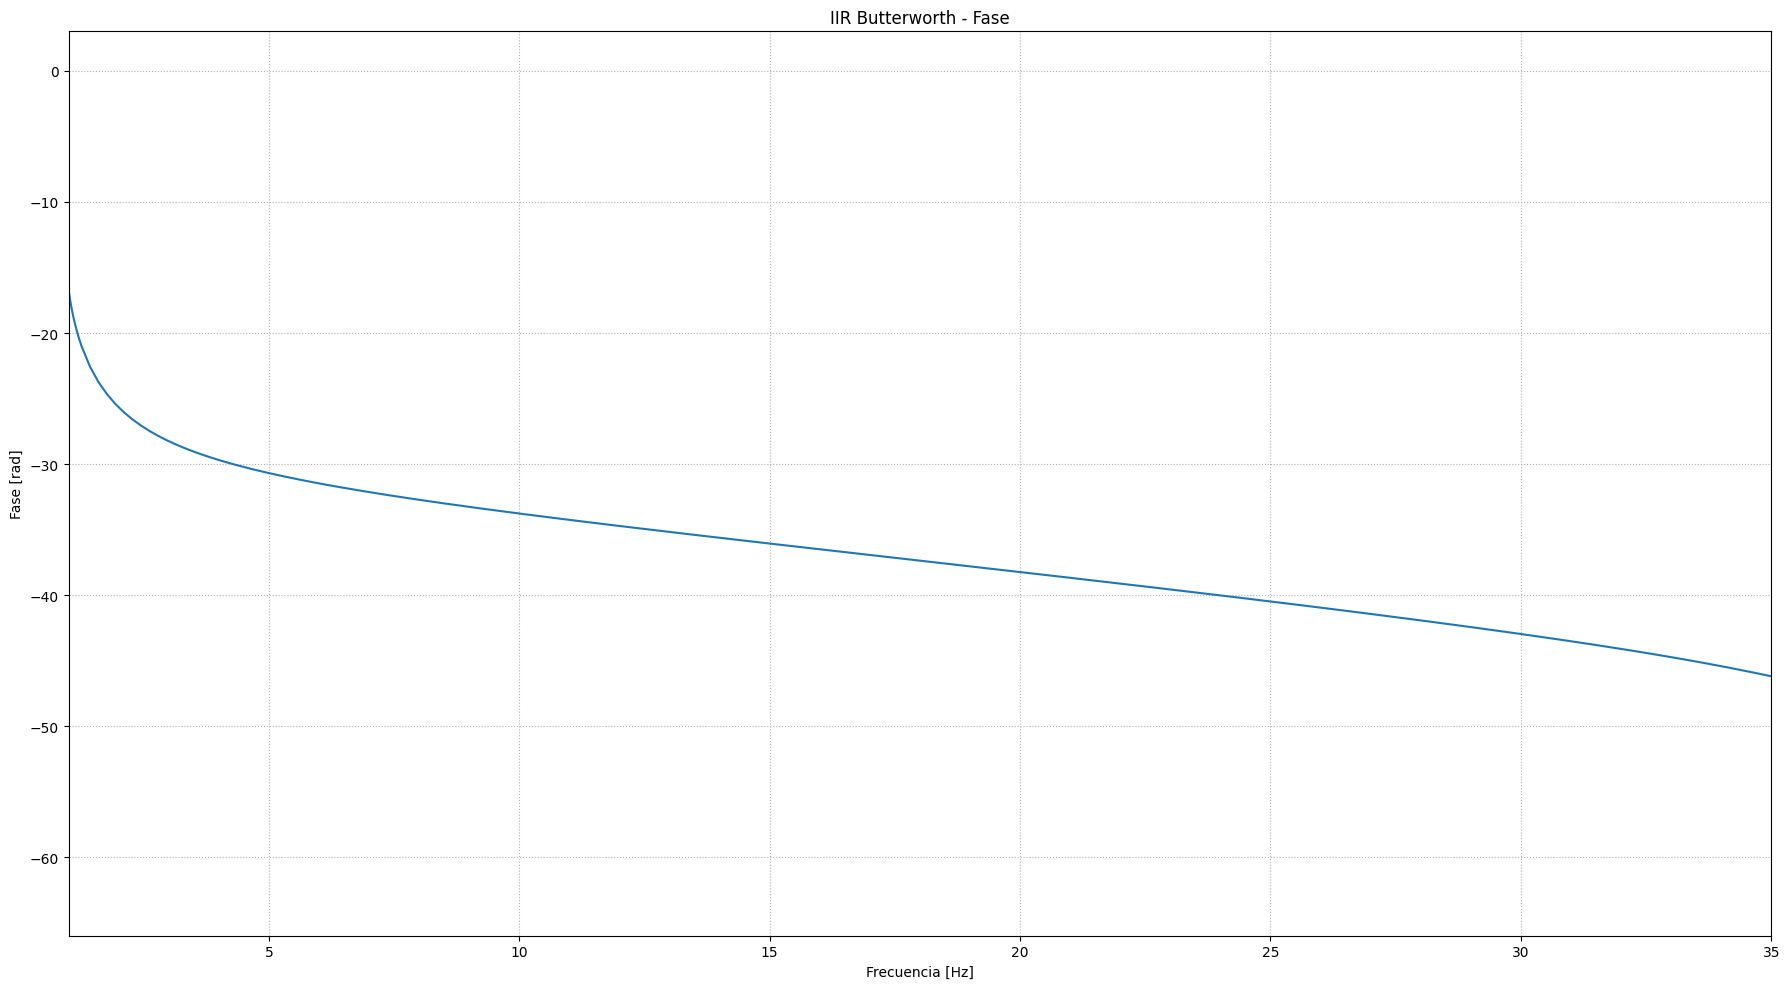

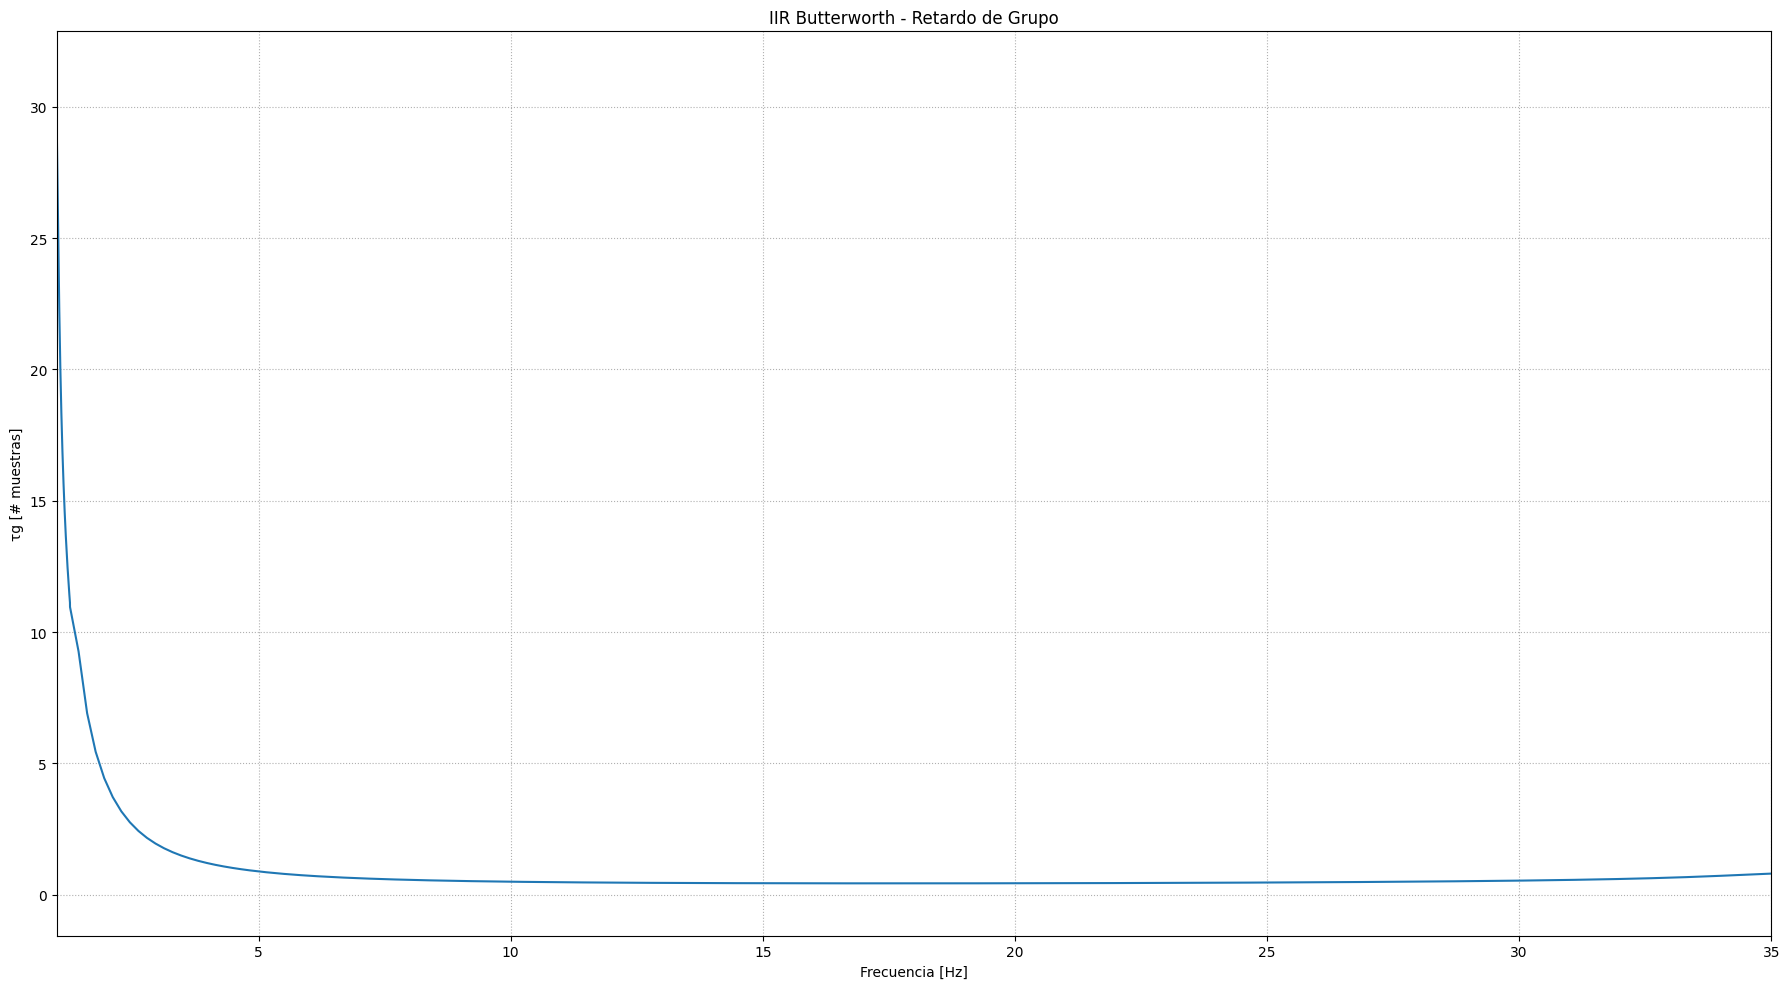

In [83]:
# GRAFICOS Butterworth 
# MODULO
plt.figure(figsize=(18,10))
plt.plot(omega_butter, 20*np.log10(abs(resp_freq_butter) + 1e-12), label="FIR")
plt.title('IIR Butterworth - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(omega_butter, phase_butter)
plt.title('IIR Butterworth - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(ww, gd_butter)
plt.title('IIR Butterworth - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

### *Cauer o elíptico*

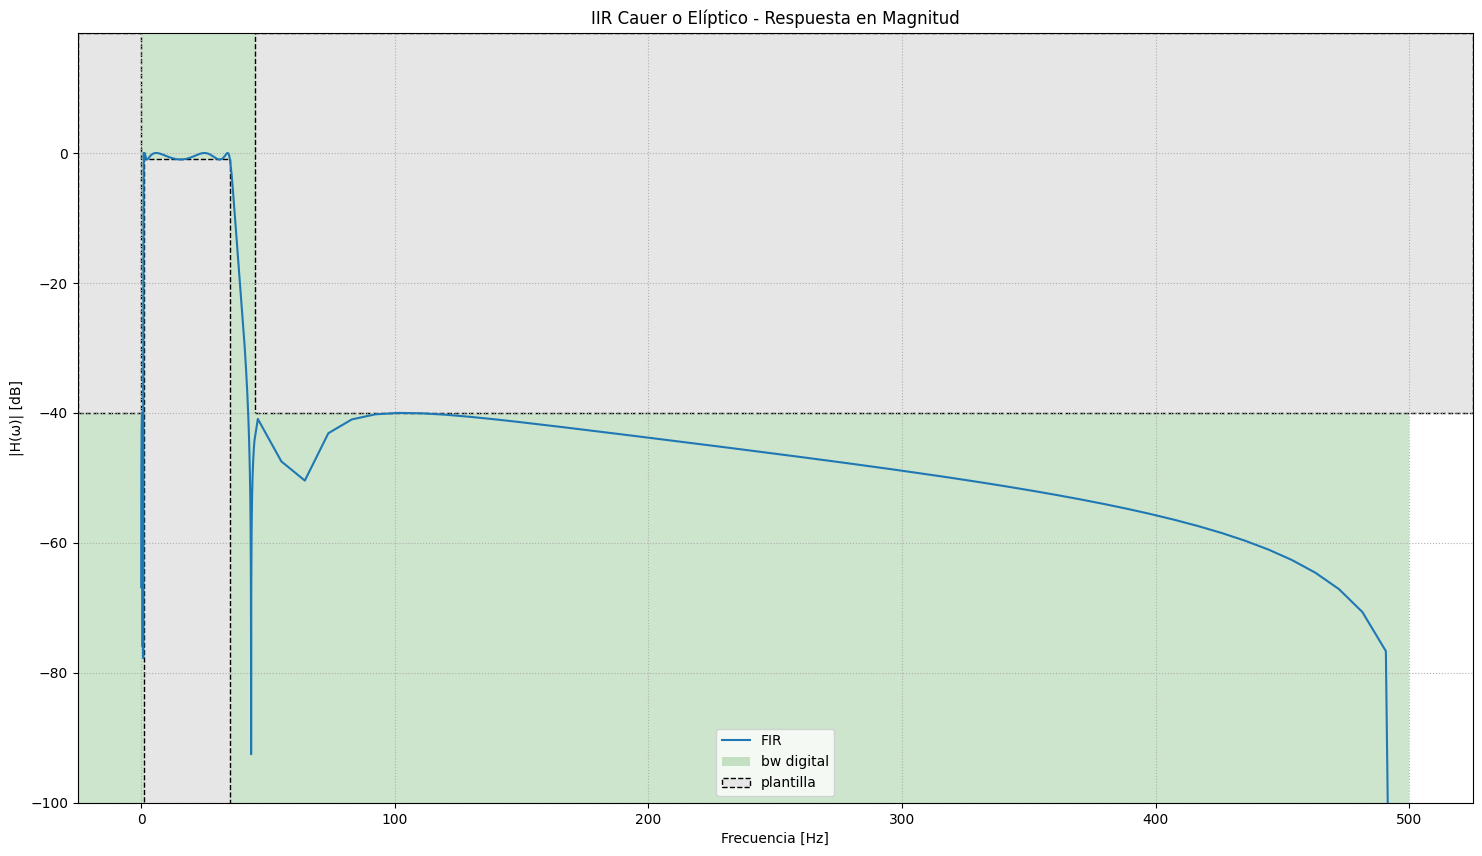

<Figure size 640x480 with 0 Axes>

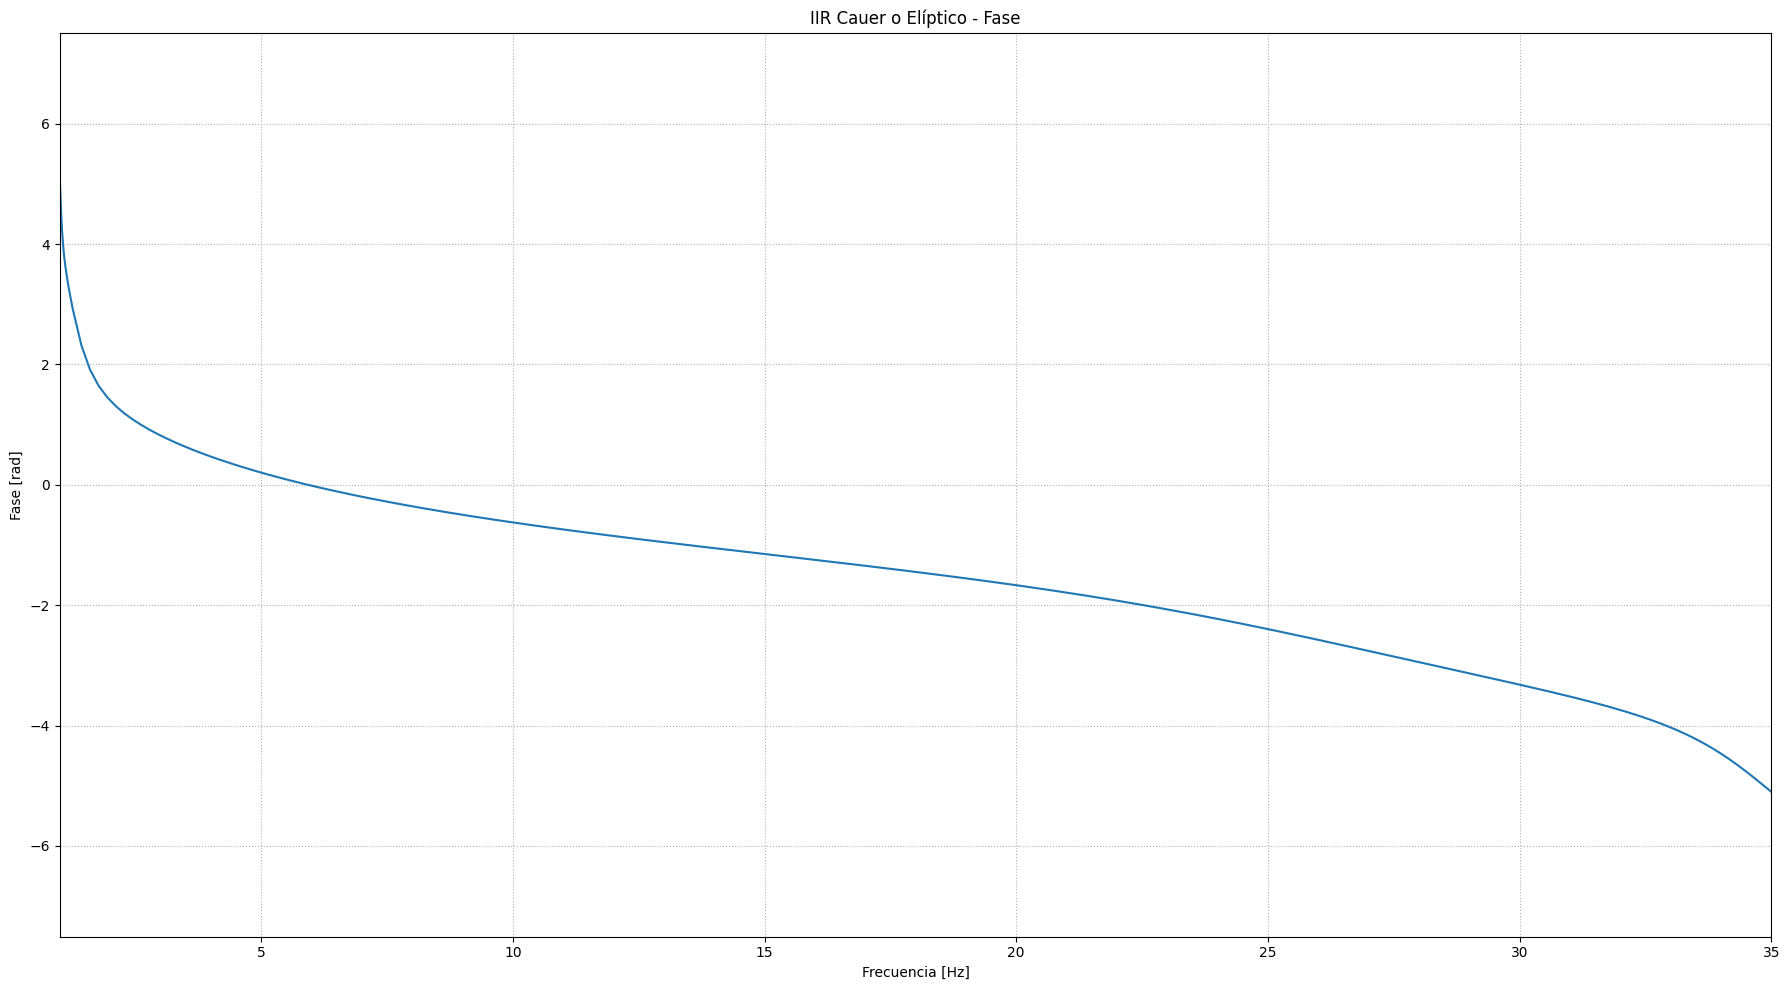

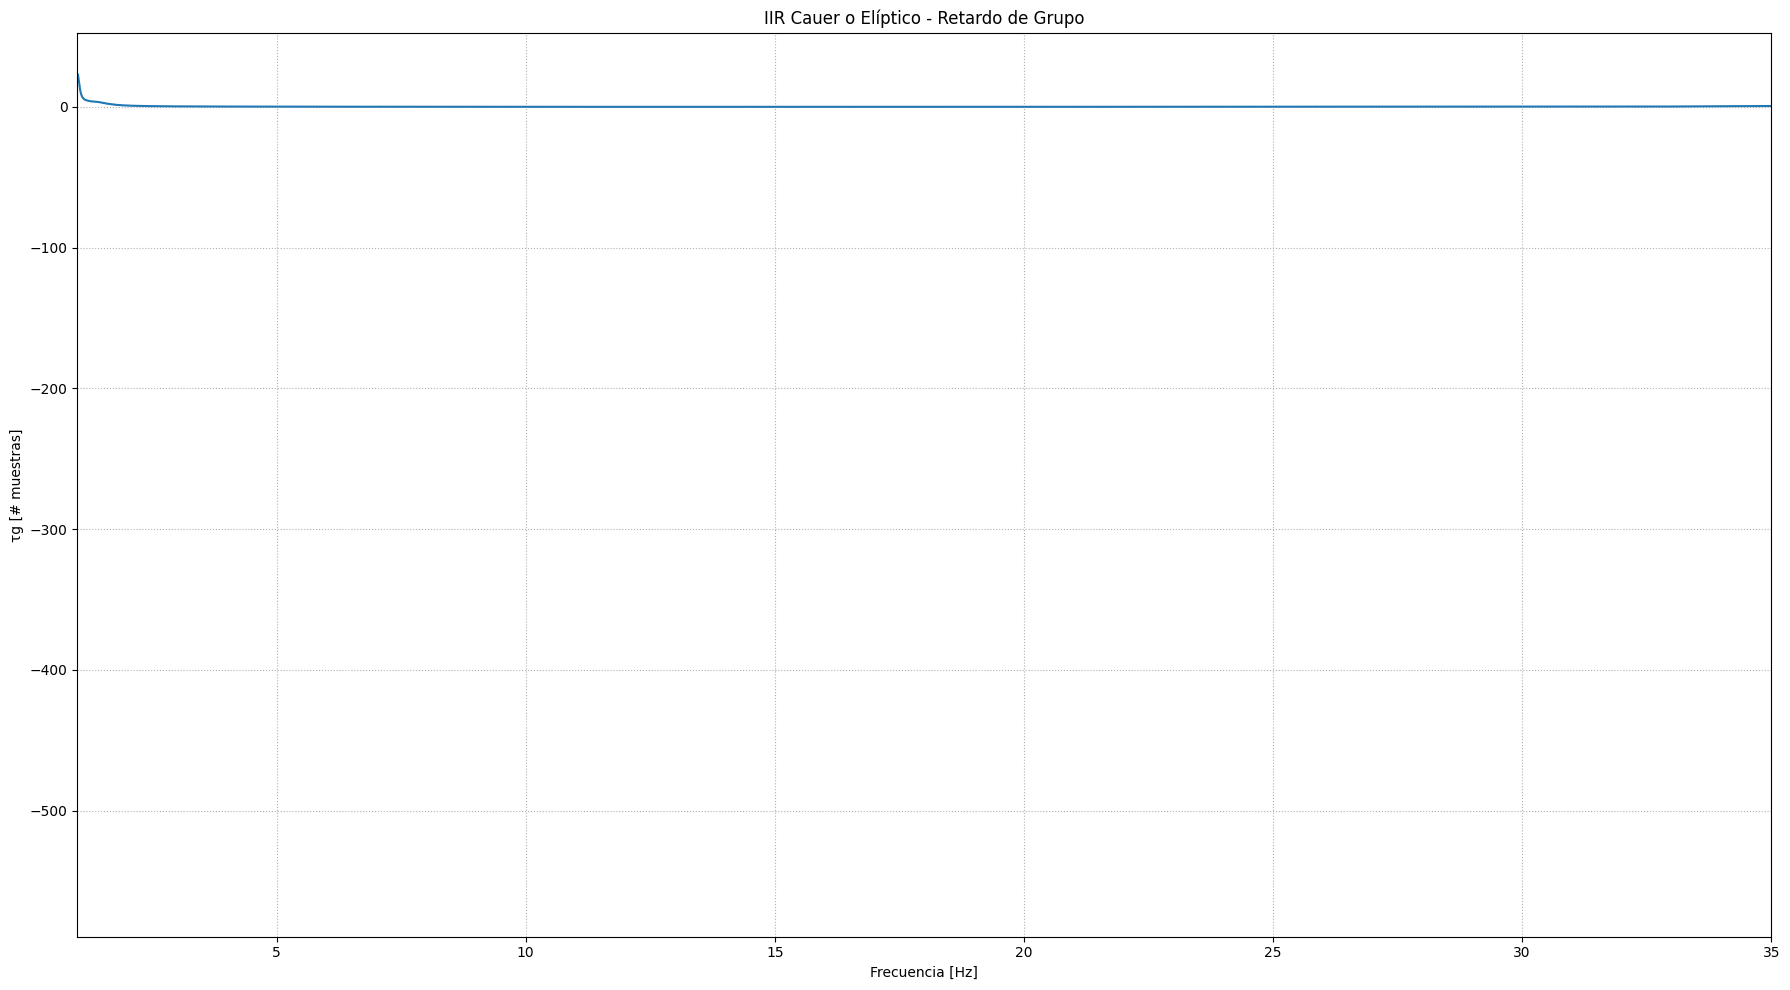

In [84]:
# GRAFICOS Cauer
# MODULO
plt.figure(figsize=(18,10))
plt.plot(omega_cauer, 20*np.log10(abs(resp_freq_cauer)), label="FIR")
plt.title('IIR Cauer o Elíptico - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(omega_cauer, phase_cauer)
plt.title('IIR Cauer o Elíptico - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(ww, gd_cauer)
plt.title('IIR Cauer o Elíptico - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

### *Chebyshev tipo II*

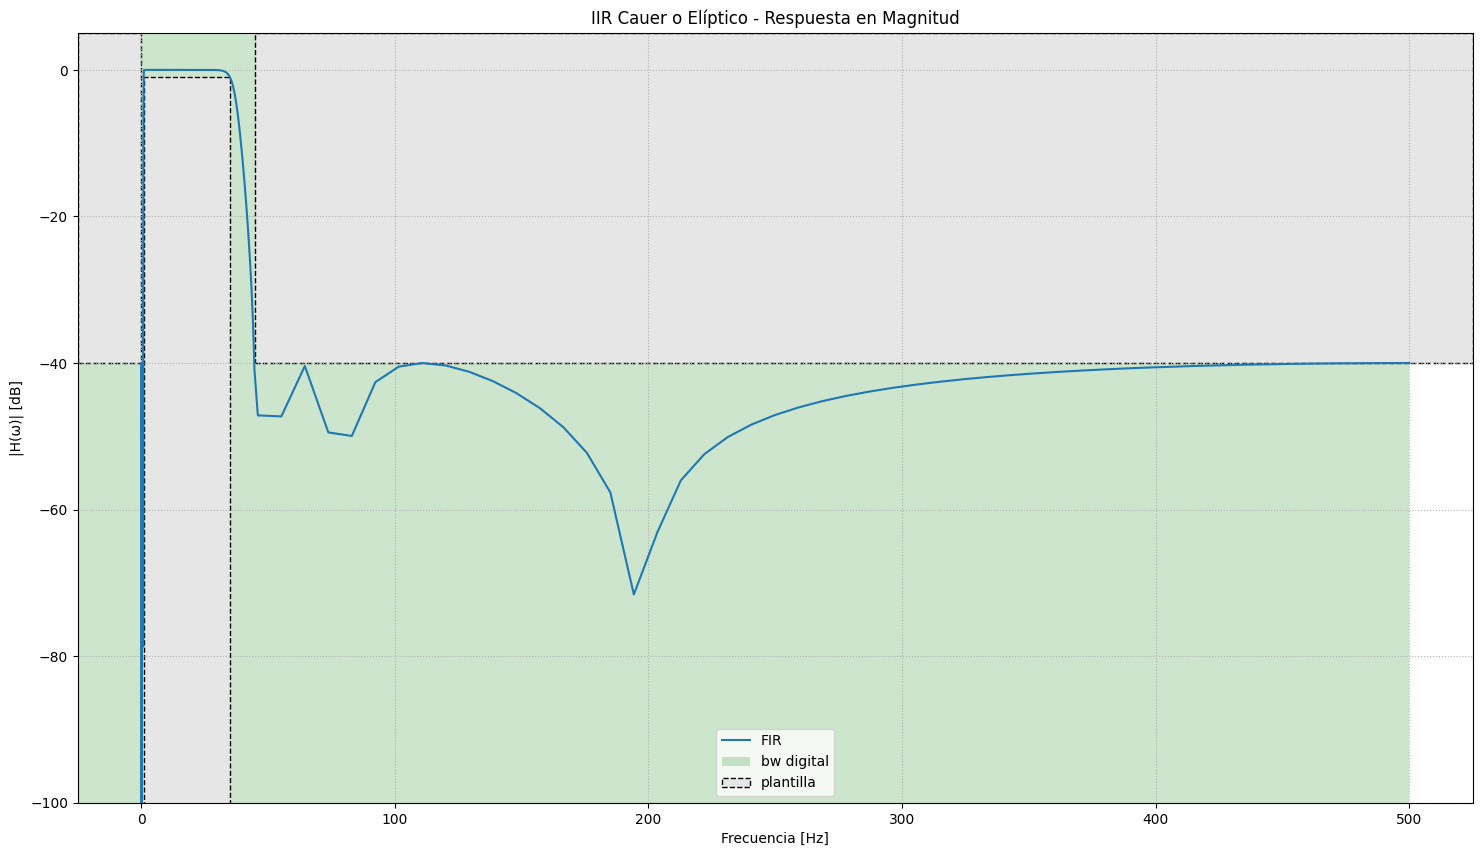

<Figure size 640x480 with 0 Axes>

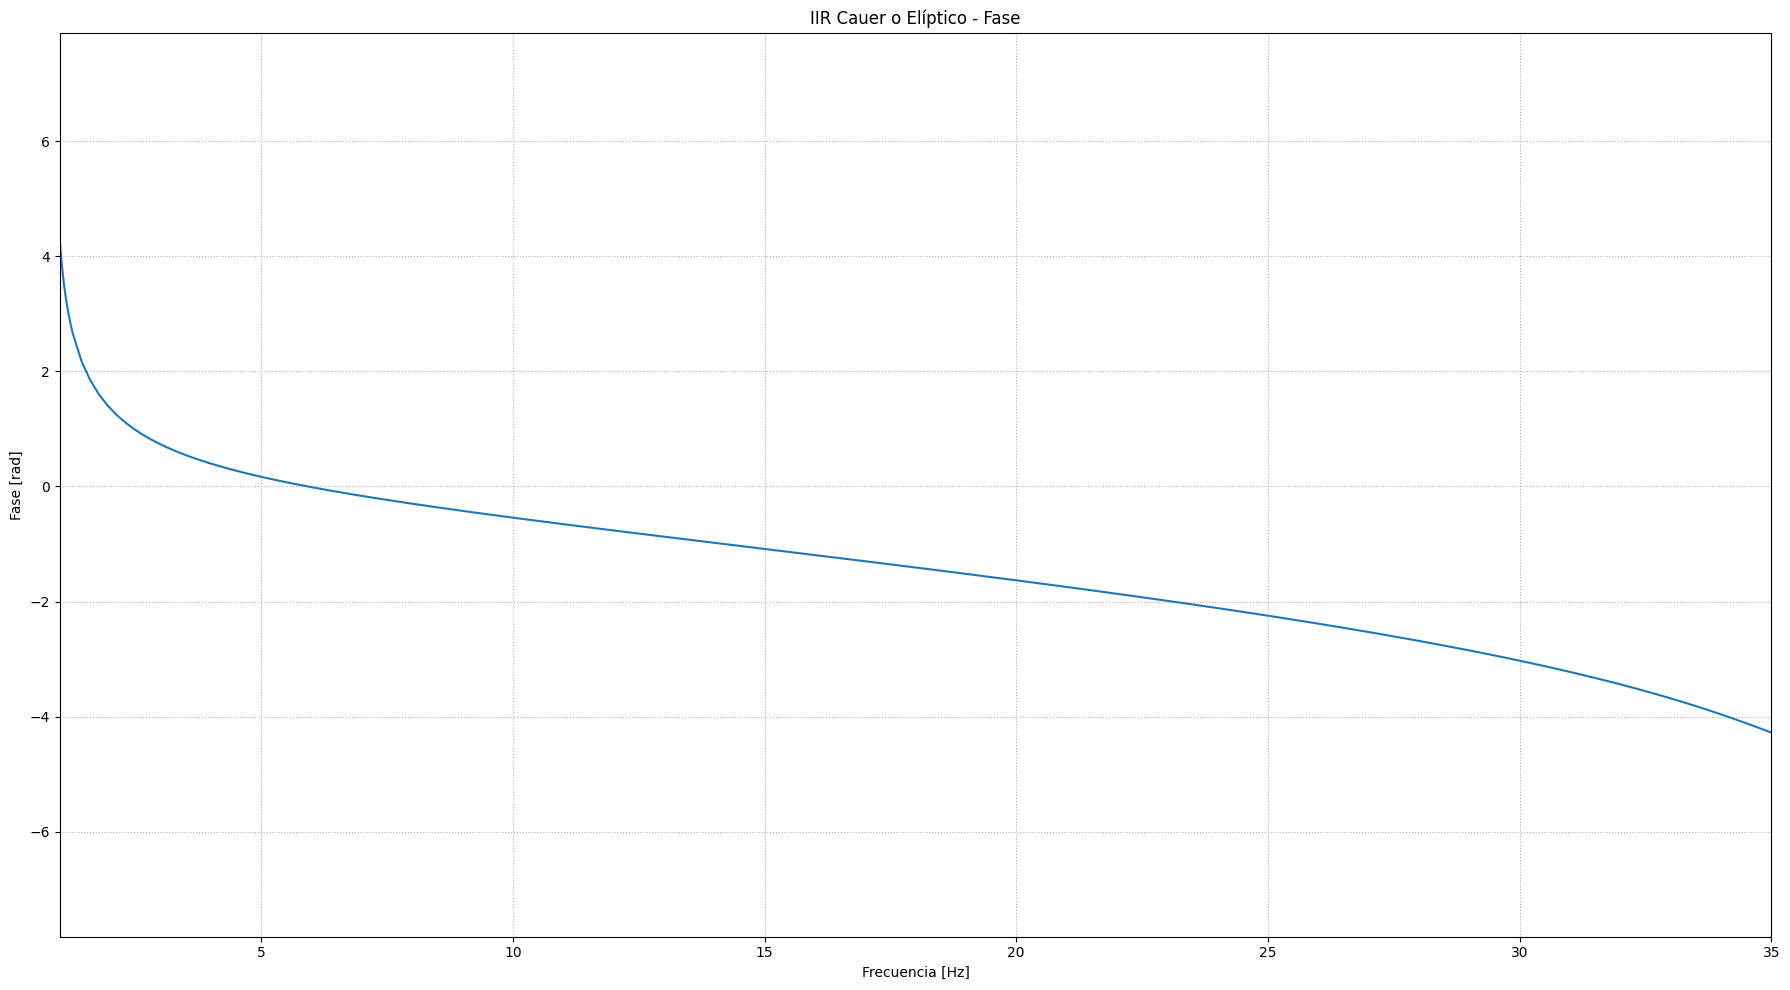

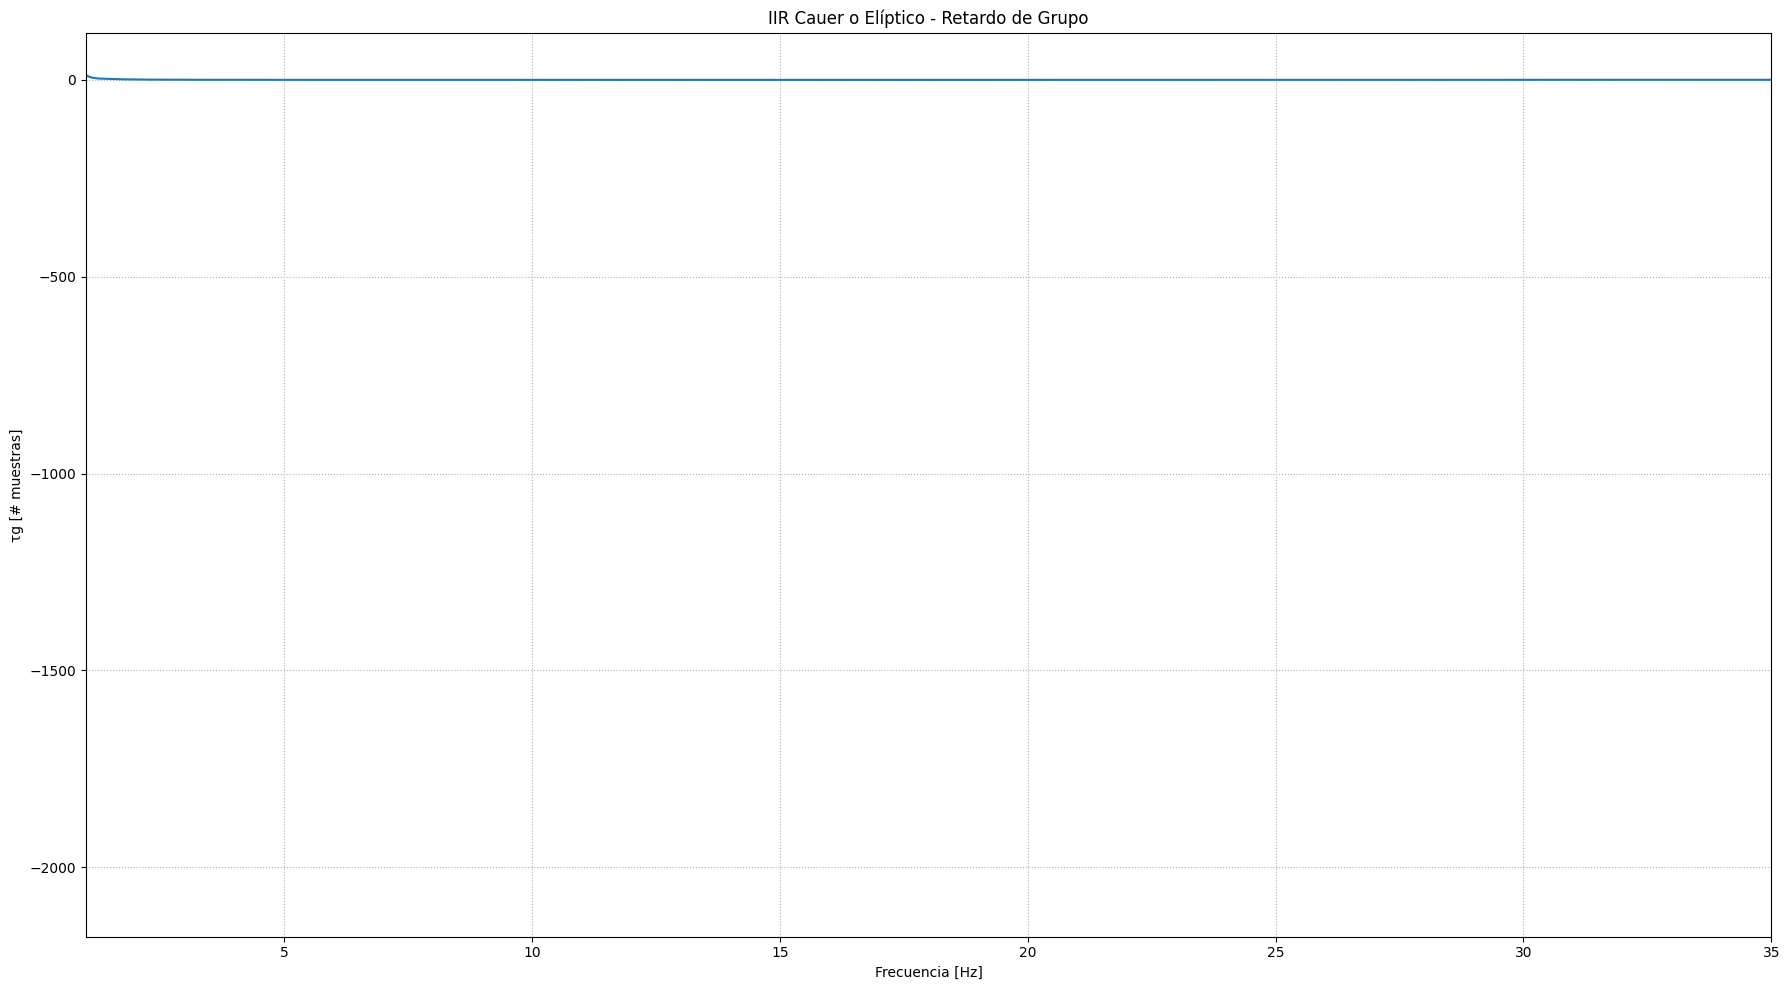

In [85]:
# GRAFICOS Chebysehv tipo 2
# MODULO
plt.figure(figsize=(18,10))
plt.plot(omega_cheby2, 20*np.log10(abs(resp_freq_cheby2)), label="FIR")
plt.title('IIR Cauer o Elíptico - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(omega_cheby2, phase_cheby2)
plt.title('IIR Cauer o Elíptico - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(ww, gd_cheby2)
plt.title('IIR Cauer o Elíptico - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

## *Aplicación de los filtros al ECG*

Posteriormente, los filtros fueron aplicados sobre la señal *ECG* mediante la función `sosfilt()`, obteniendo una implementación causal del filtrado. 

In [86]:
# Como implementamos el filtro? 
# Para usarlo necesitamos la señal 
import scipy.io as sio

fs_ecg = 1000 # Hz

# ECG con ruido 
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']. flatten()

ECG_f_butter = sig.sosfilt(sos_f_butter, ecg_one_lead)
ECG_f_cauer = sig.sosfilt(sos_f_cauer, ecg_one_lead)
ECG_f_cheby2 = sig.sosfilt(sos_f_cheby2, ecg_one_lead)

Debido a que los filtros IIR presentan fase no lineal, y por lo tanto introducen distorsiones temporales, también se implementó un filtrado bidireccional utilizando `sosfiltfilt()`. Este procedimiento realiza un filtrado hacia adelante y hacia atrás, eliminando el retardo de grupo. 

Dado que el filtro se aplica dos veces, las especificaciones de ripple y atenuación fueron ajustadas previamente para que el resultado final continúe satisfaciendo la plantilla original. 

In [87]:
# Vamos a usar sosfiltfilt
# Hace un backward - fordward 
# Es un filtrado bidireccional, y lo que asume es como que pasas dos veces por la respuesta de modulo 
# Es decir, voy a tener 2alfa max de ripple, y 2alfa min de atenuacion 
# Y en dB es como tener el doble de dB
# El efecto de invertir en tiempo es util para el retardo de fase? Neutraliza la fase, sincroniza temporalmente la señal original con la filtrada

sos_ff_butter = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'butter', output = 'sos', fs = fs)
sos_ff_cauer = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'cauer', output = 'sos', fs = fs)
sos_ff_cheby2 = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'cheby2', output = 'sos', fs = fs)

ECG_ff_butter = sig.sosfiltfilt(sos_ff_butter, ecg_one_lead)
ECG_ff_cauer = sig.sosfiltfilt(sos_ff_cauer, ecg_one_lead)
ECG_ff_cheby2 = sig.sosfiltfilt(sos_ff_cheby2, ecg_one_lead)

## *Evaluación del desempeño*

Finalmente, se analizaron distintas regiones de interés de la señal *ECG*. Se seleccionaron zonas con presencia de ruido para verificar la capacidad de atenuación de las interferencias y zonas relativamente limpias para comprobar que el filtrado no introdujera modificaciones significativas sobre la señal original. 

### *Regiones de interés sin ruido*

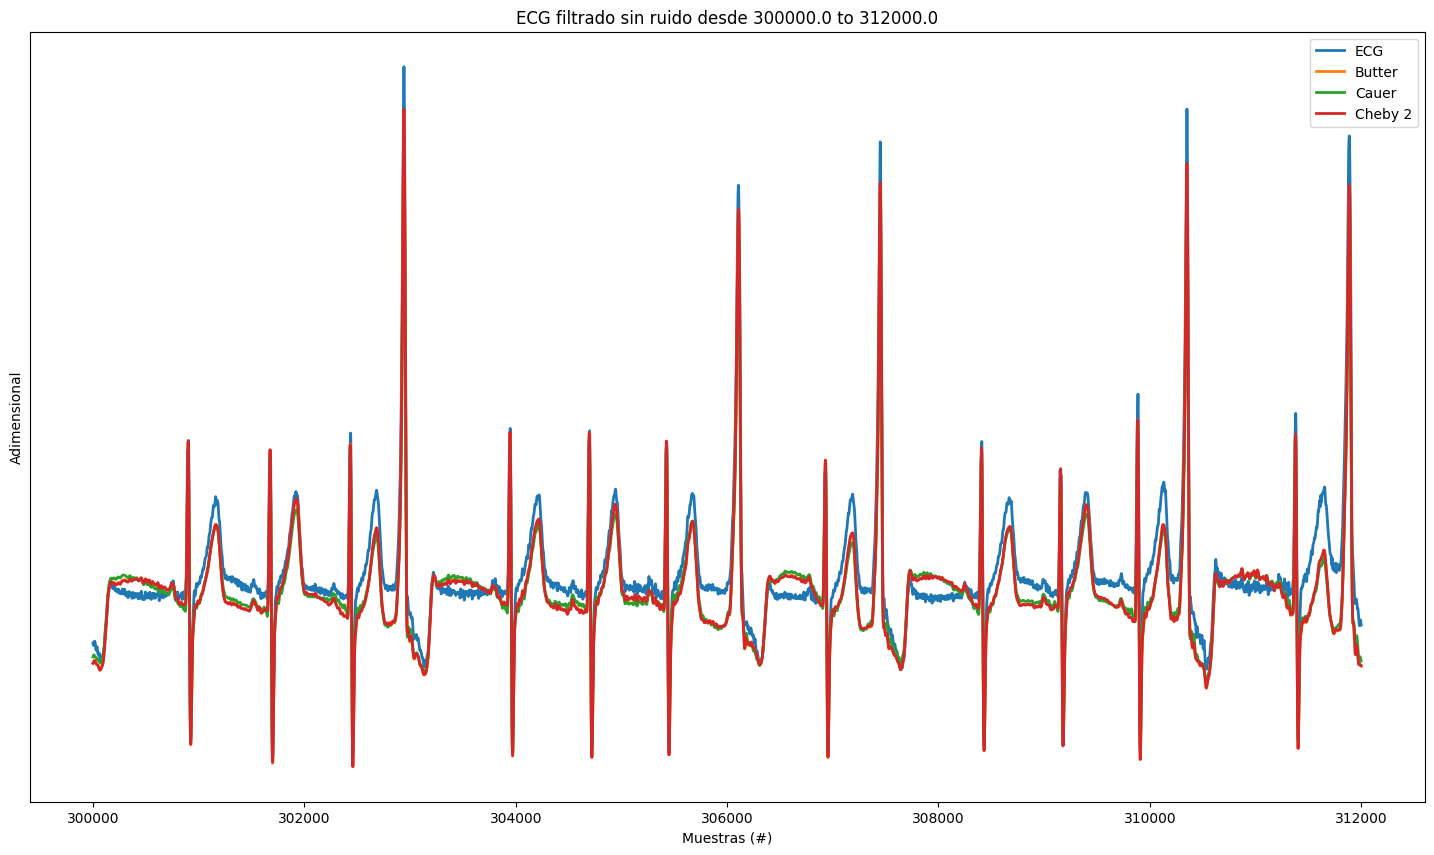

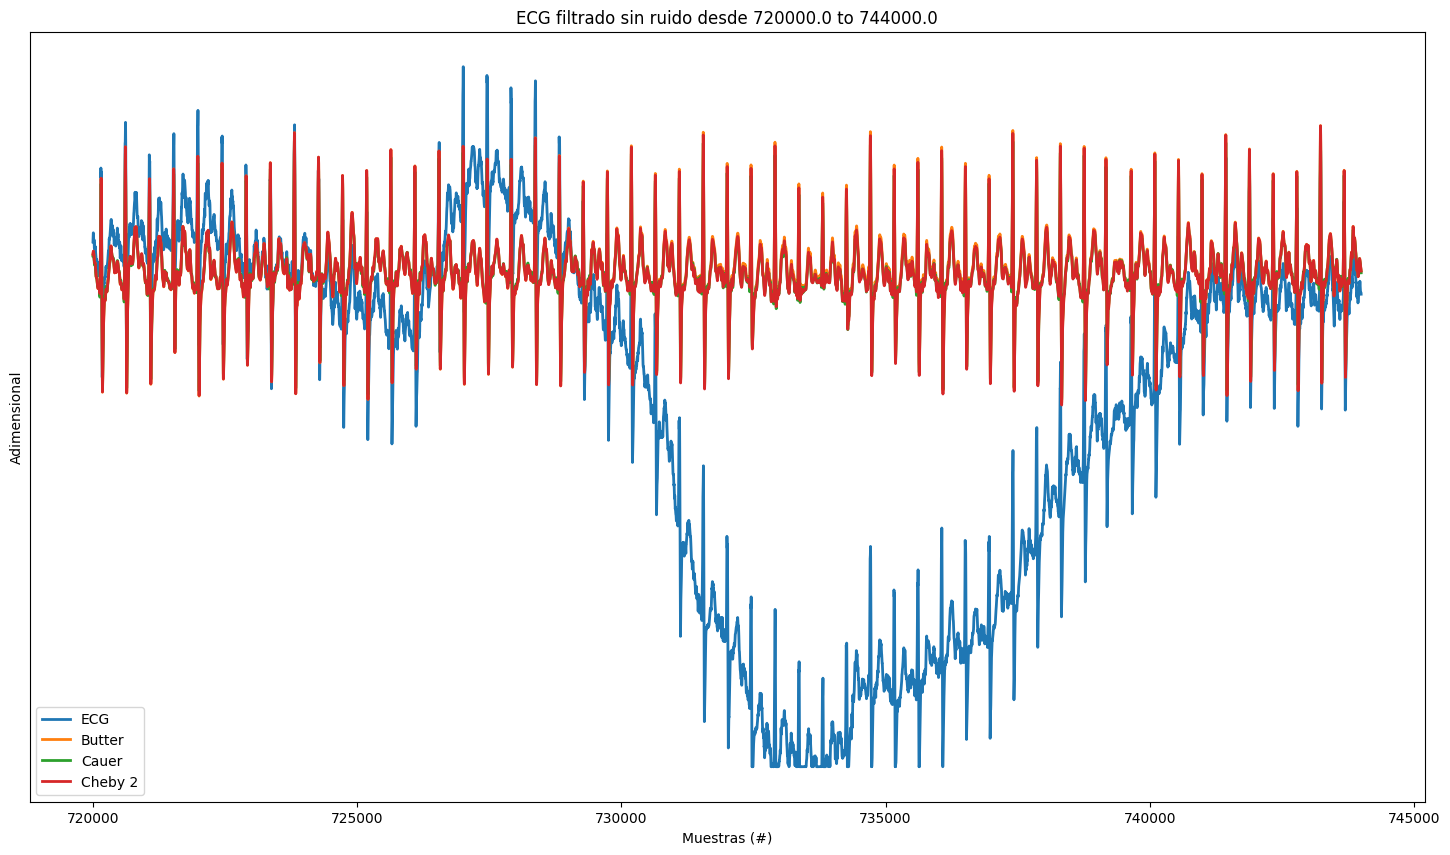

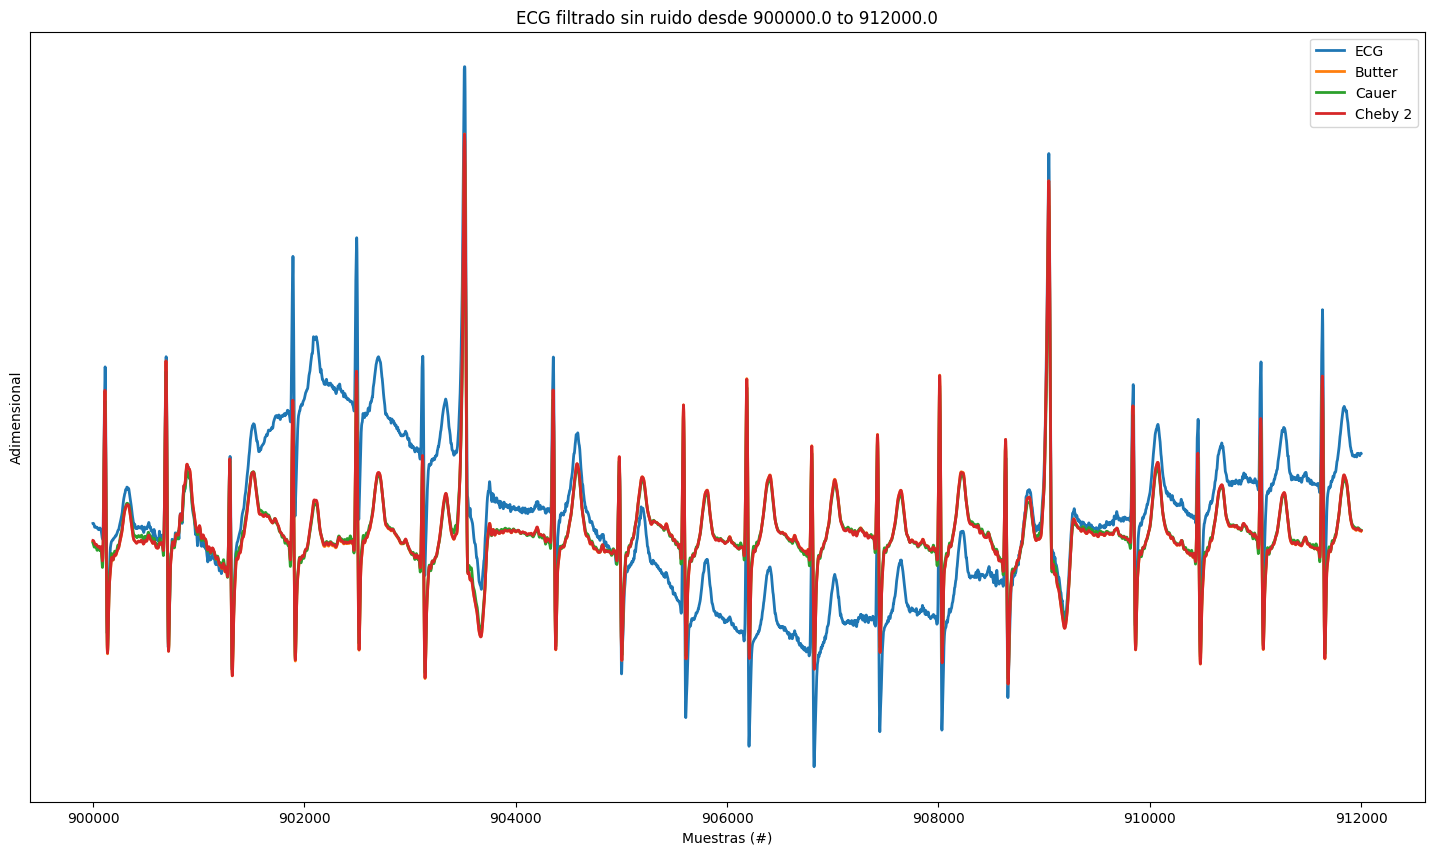

In [88]:
# Regiones de interés sin ruido
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(figsize=(18,10))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_ff_butter[zoom_region], label='Butter', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cauer[zoom_region], label='Cauer', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cheby2[zoom_region], label='Cheby 2', linewidth=2)
   
    plt.title('ECG filtrado sin ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

### *Regiones de interés con ruido*

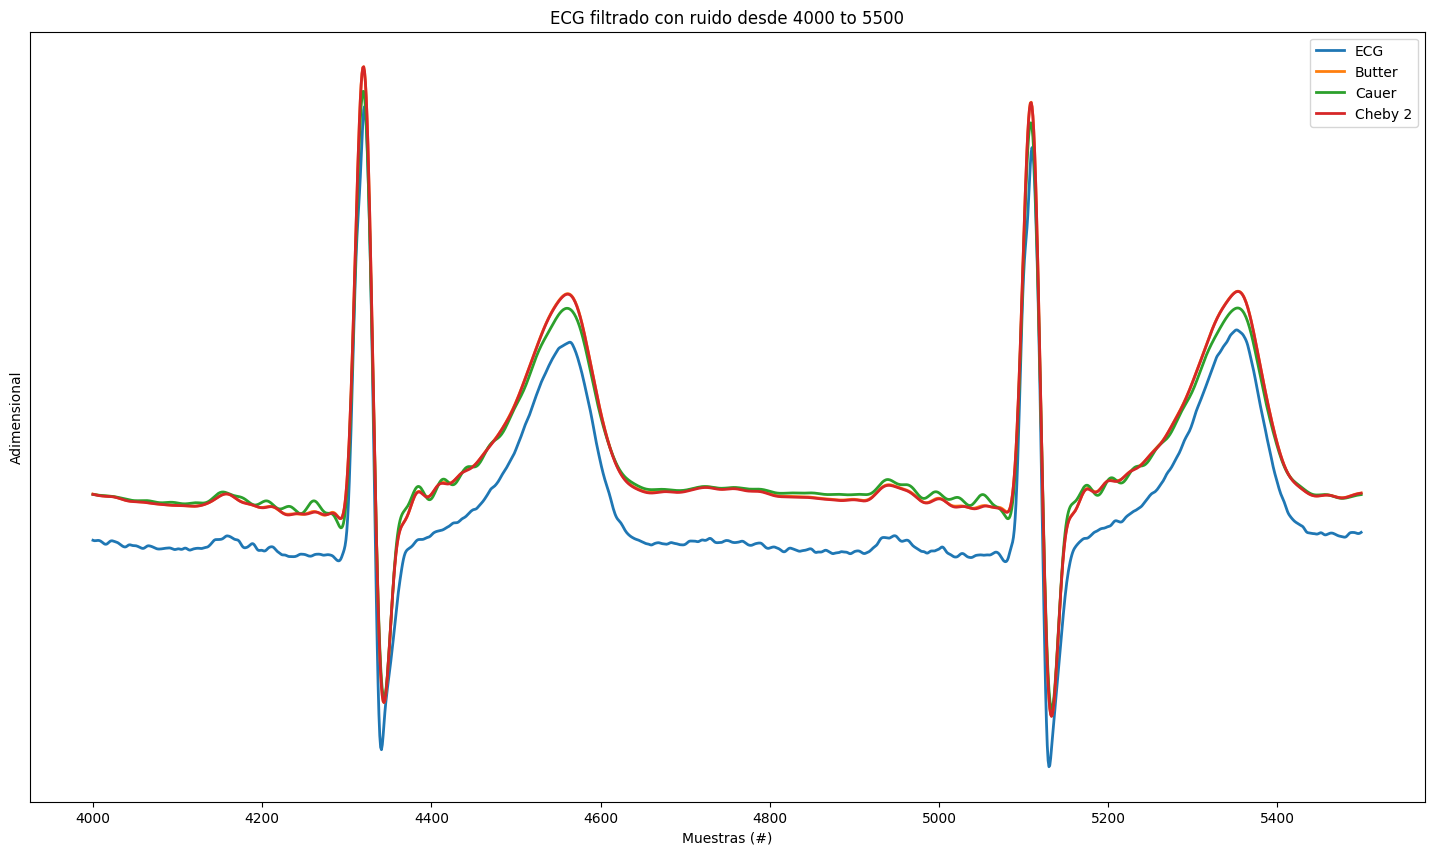

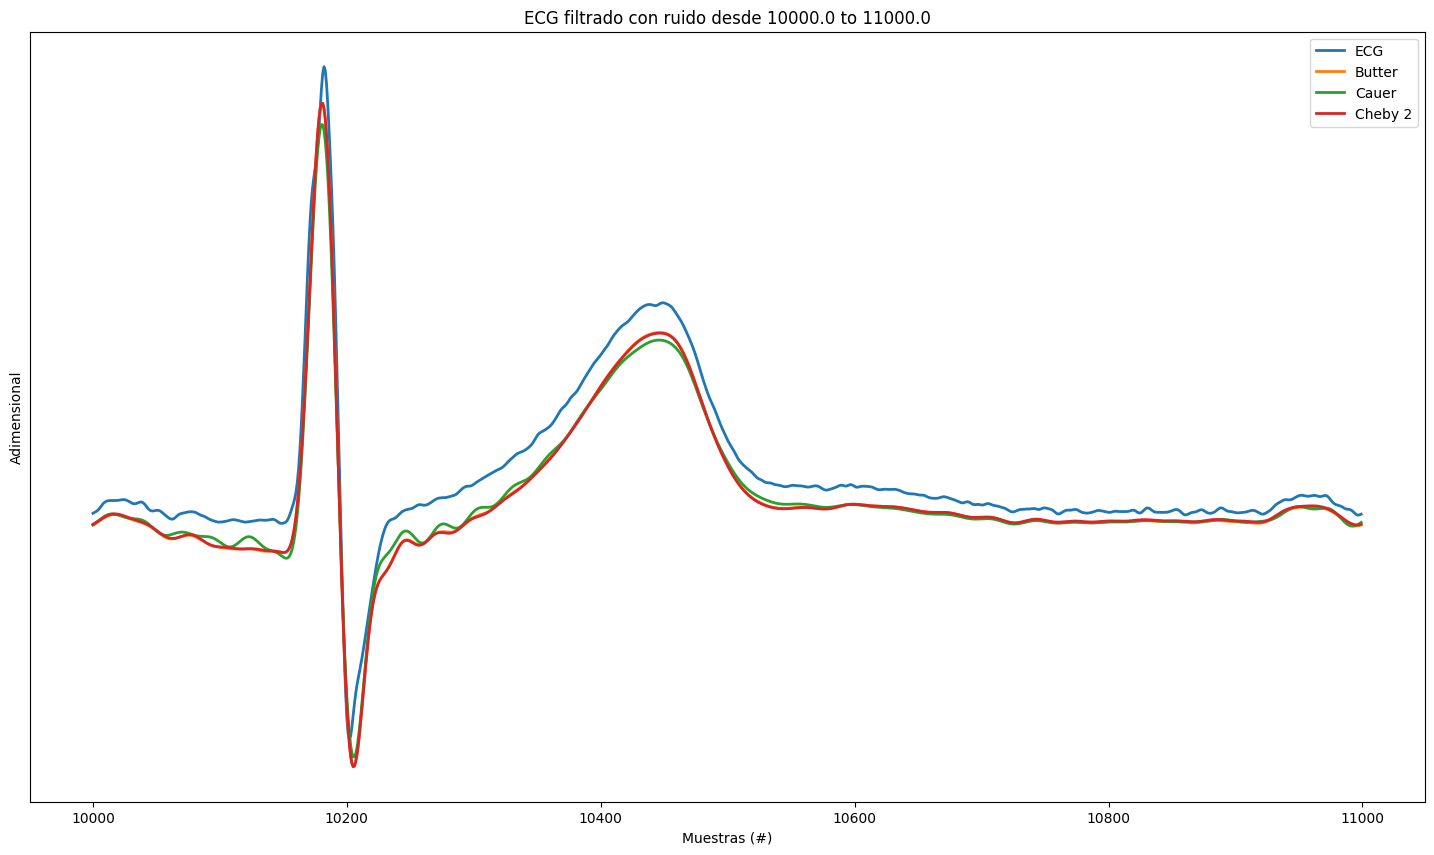

In [89]:
# Regiones de interés con ruido
 
N = len(ecg_one_lead) 
cant_muestras = N

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(figsize=(18,10))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_ff_butter[zoom_region], label='Butter', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cauer[zoom_region], label='Cauer', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cheby2[zoom_region], label='Cheby 2', linewidth=2)
   
    plt.title('ECG filtrado con ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

## *Filtros FIIR*

## *Definición de la plantilla*

Para el diseño de los filtros *FIR* se observó que las especificaciones originales resultaban difíciles de satisfacer de manera directa. Por este motivo, se definió una plantilla auxiliar más exigente, denominada *"plantilla hack"*, caracterizada por bandas de transición más estrechas. 

El objetivo de esta modificación fue obtener filtros que, una vez diseñados, lograran cumplir adecuadamente la plantilla original utilizada como referencia durante la evaluación. 

In [90]:
# HACK para la plantilla de diseño
wp1_hack = 1 # Hz
wp2_hack = 35 # Hz --> 30 es aprox el ancho de banda que nos dio en la TS5
ws1_hack = .3 # Hz 
ws2_hack = 35.4 # Hz
gpass_hack = 1 # dB
gstop_hack = 40 # dB 

wp_hack = (wp1_hack, wp2_hack) # Comienzo y fin de la banda de paso
ws_hack = (ws1_hack, ws2_hack) # Comienzo y fin de la banda de stop

## *Diseño de los filtros*

Se implementaron dos metodologías de diseño de *FIR*: 

- Método de ventanas mediante `firwin2()`
- Método de cuadrados mínimos mediante `firls()`

Durante el proceso de diseño se analizaron distintas configuraciones de simetría. Sin embargo, únicamente los filtros antisimétricos lograron satisfacer adecuadamente las especificaciones planteadas. Por esta razón, el análisis posterior se centró en: 

- *FIR Tipo IV* diseñado mediante ventanas.
- *FIR Tipo III* por cuadrados mínimos.

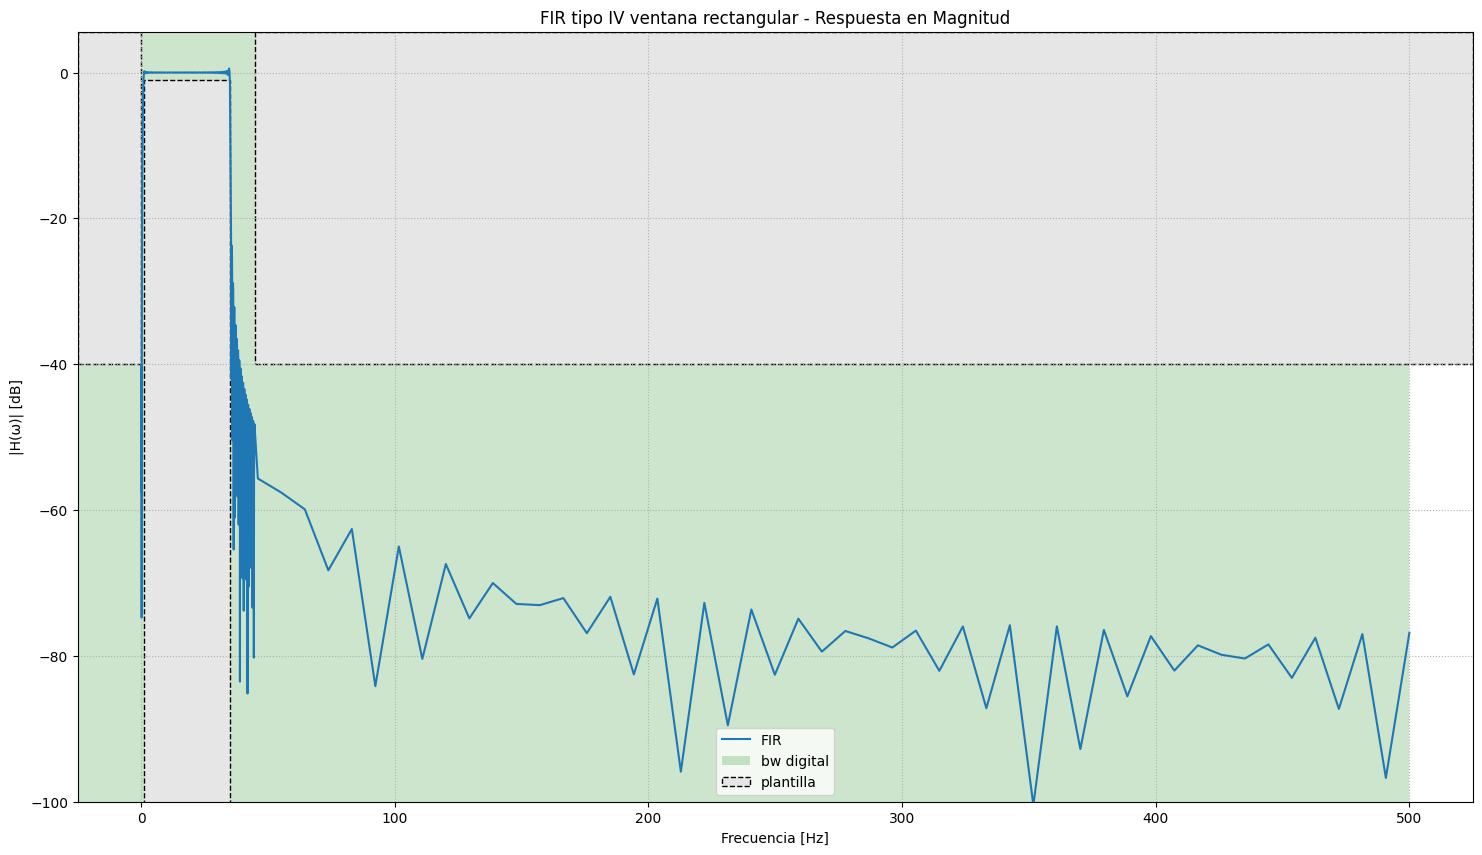

<Figure size 640x480 with 0 Axes>

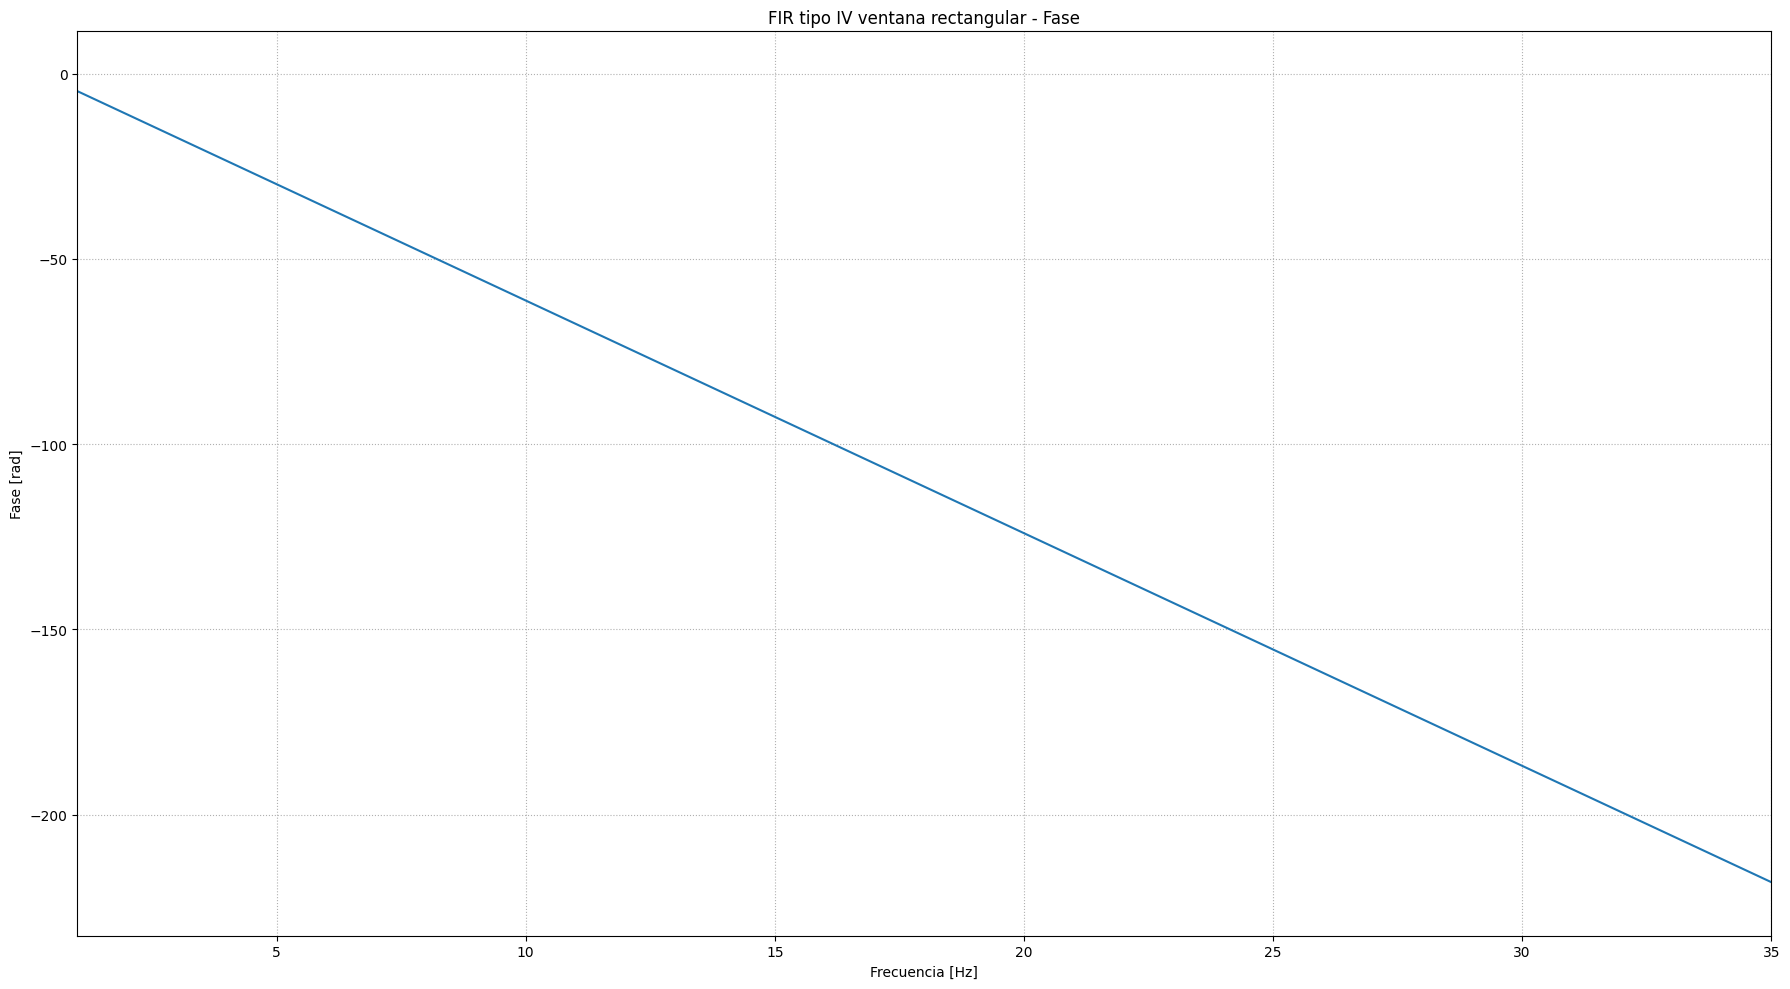

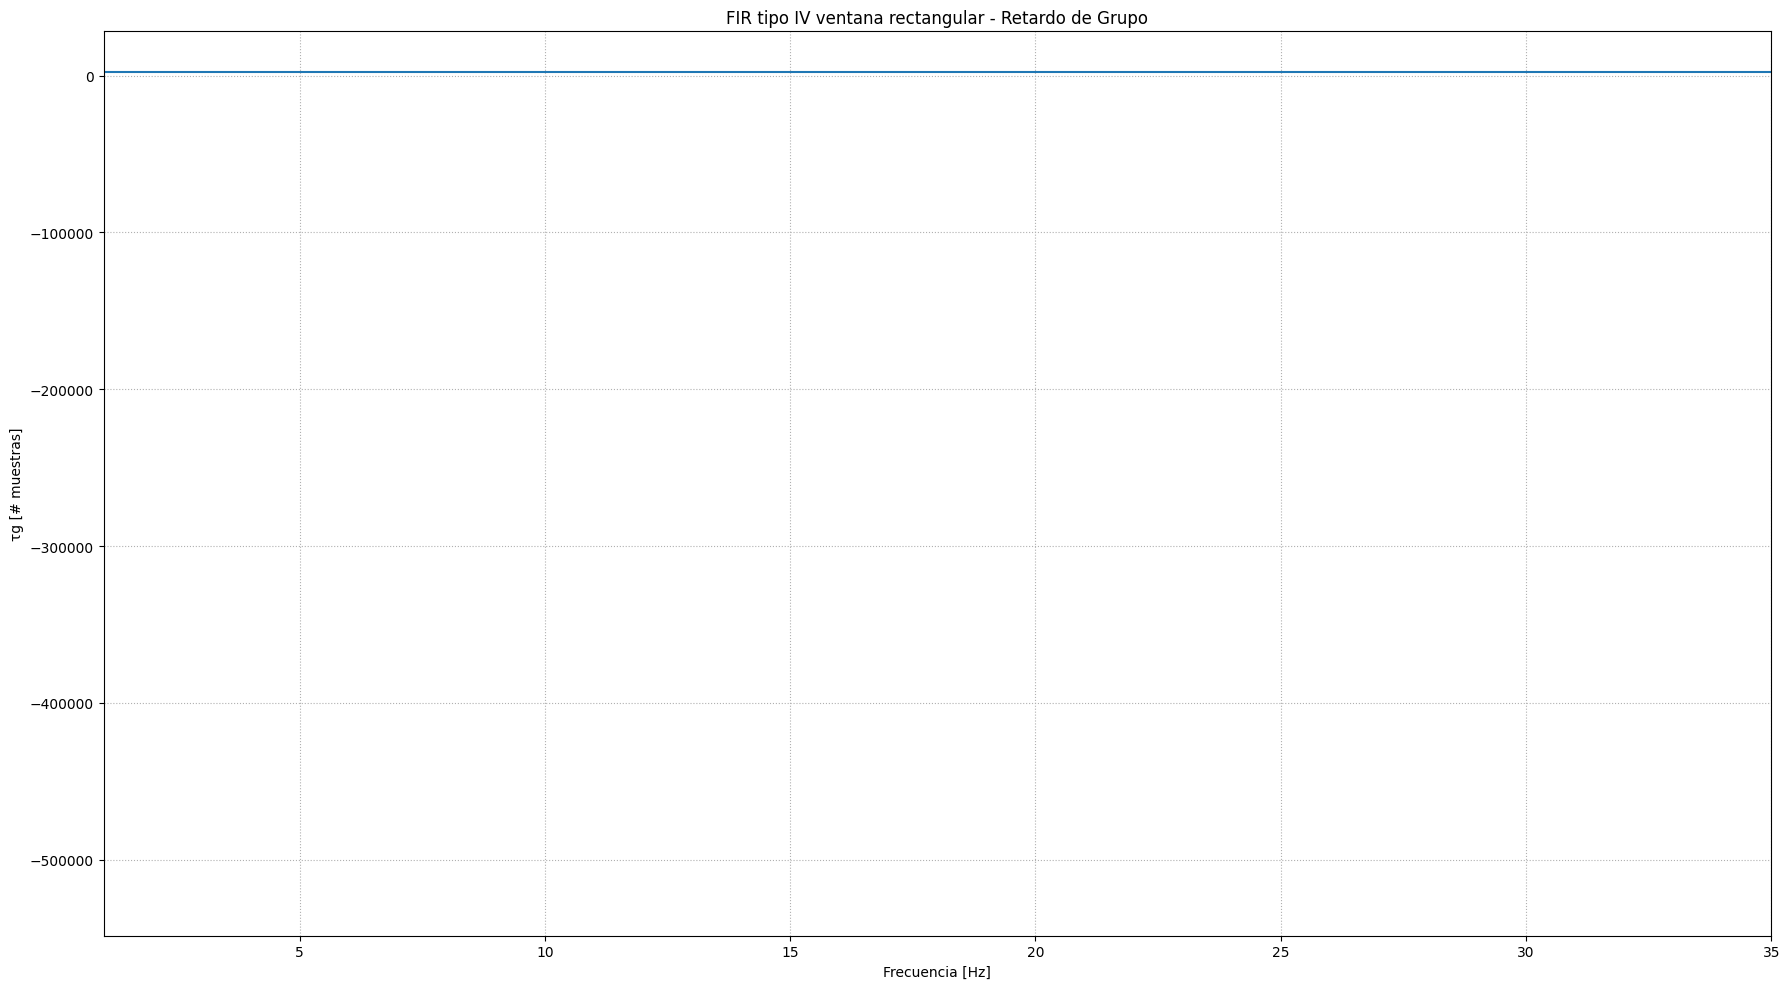

In [91]:
# FIRWIN2
numtaps = 2000
freq = np.array([0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs//2])
gain = np.array([0, 0, 1, 1, 0, 0])

#%% FIR ANTISIMETRICO con ventanas
fir_win_ant = sig.firwin2(numtaps, freq, gain, nfreqs = 2**14, window = 'boxcar', fs = fs, antisymmetric = True)

# Respuesta en frecuencia
w_fir_ant, h_fir_ant = sig.freqz(fir_win_ant, worN = ww, fs = fs)
fase_fir_ant = np.unwrap(np.angle(h_fir_ant))
gd_fir_ant = -np.diff(fase_fir_ant) / np.diff(w_fir_ant/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant, 20*np.log10(abs(h_fir_ant)), label="FIR")
plt.title('FIR tipo IV ventana rectangular - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant, fase_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant[1:], gd_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()


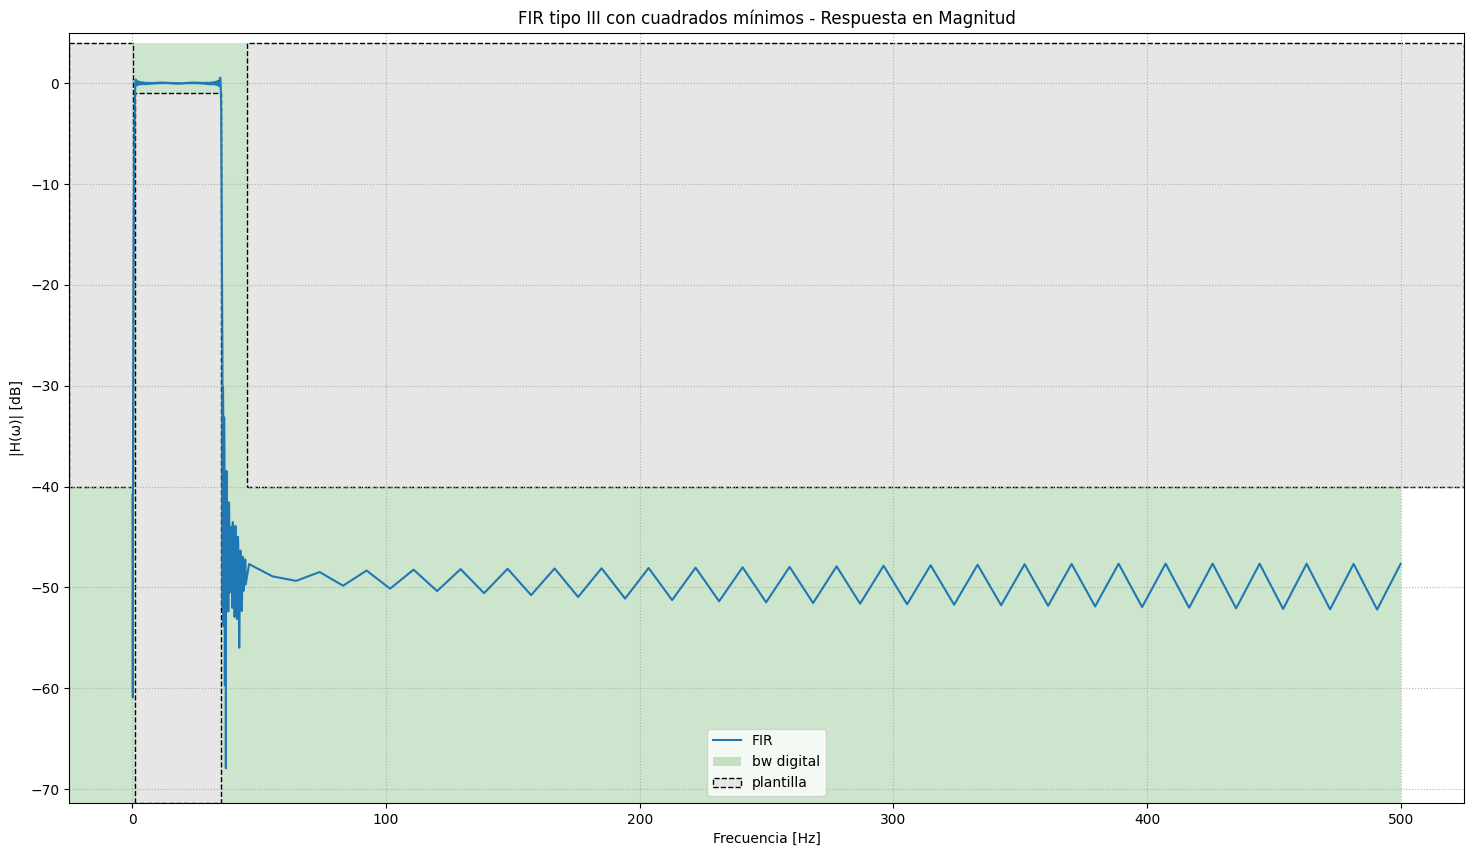

<Figure size 640x480 with 0 Axes>

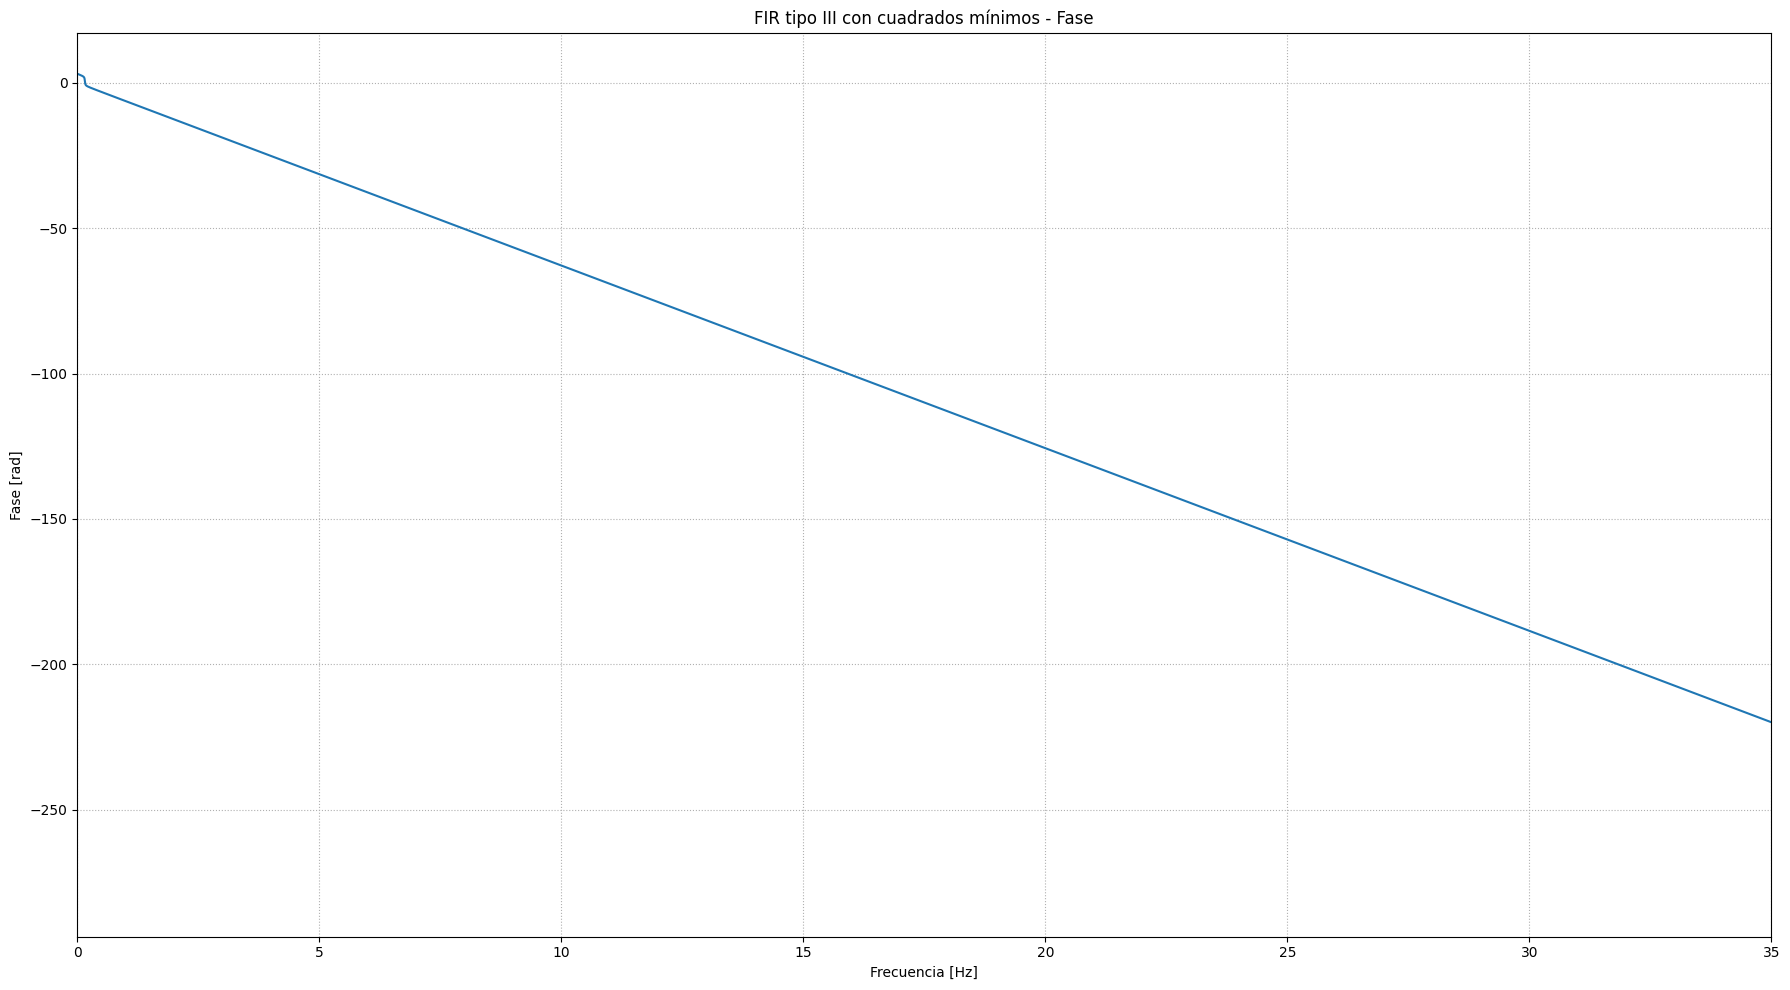

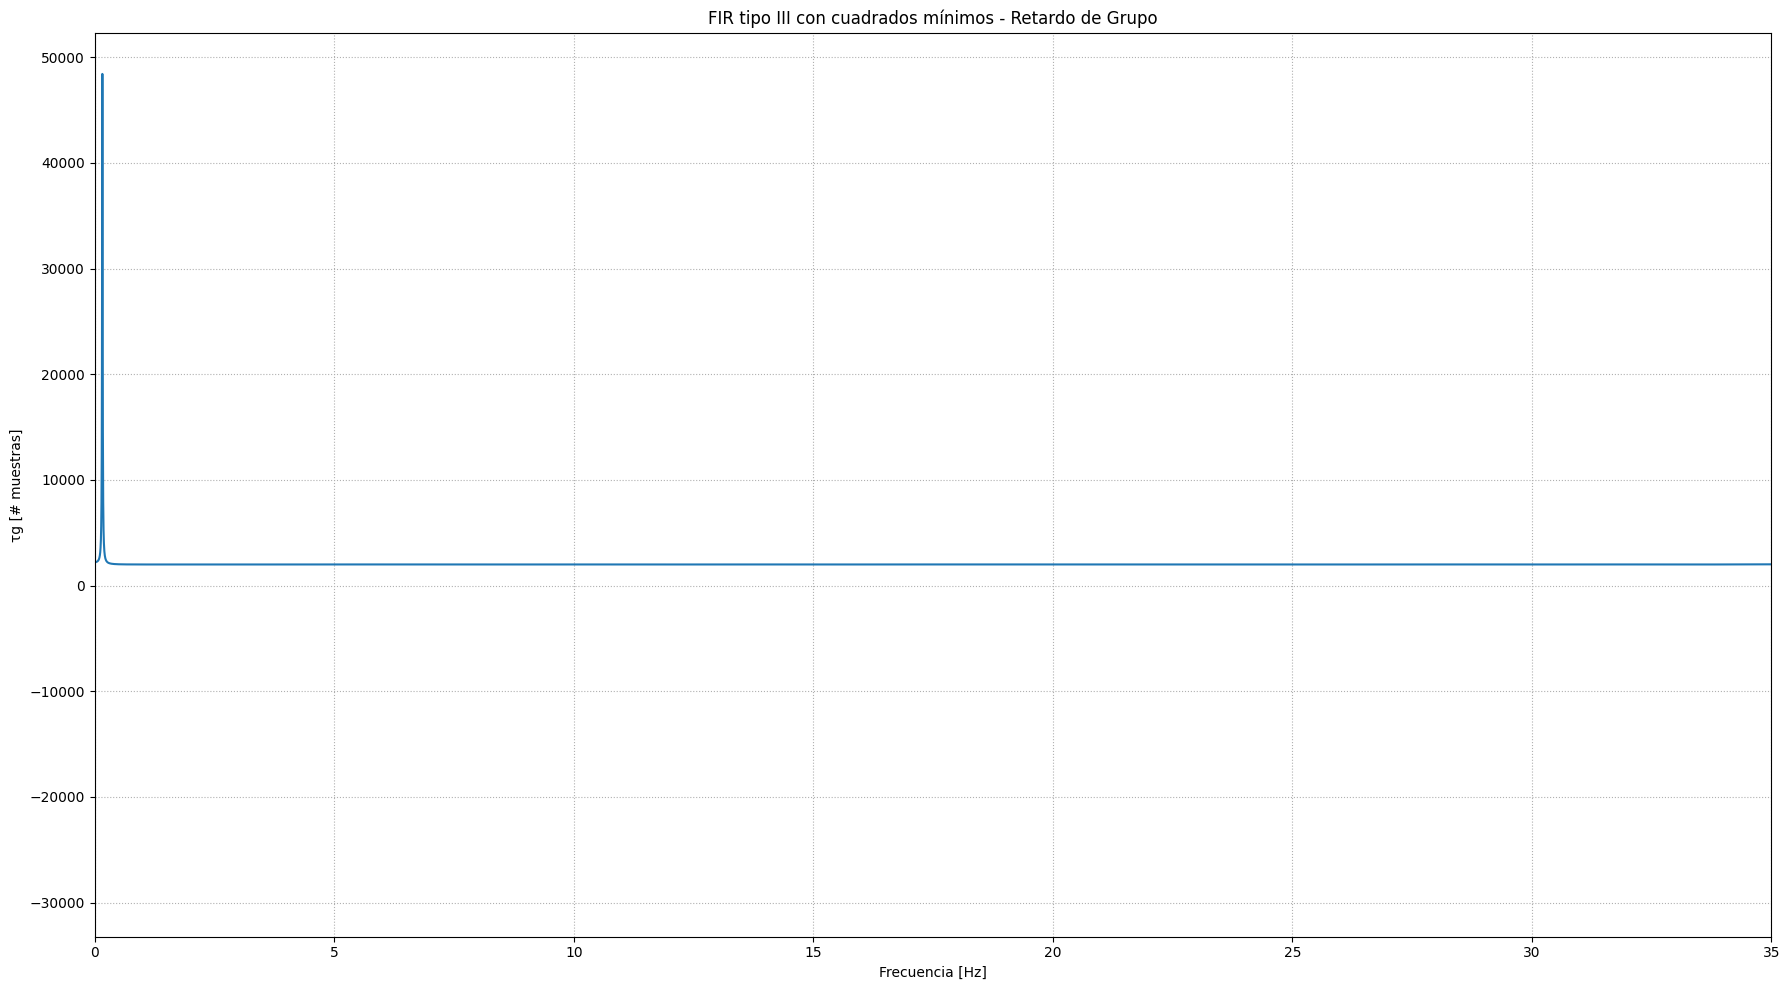

In [92]:
# FIR SIMETRICO con CUADRADOS MINIMOS 
numtaps = 2001
# Si tengo 8000 taps --> en tiempo tengo: N = 8000 y la distancia entre muestras es N*Ts = N/fs = 8segundos

freq = np.array([0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs//2]) # Tinee que ir siempre para arriba
# El fs/2 es Nyquist y es porque no esta normalizado

# Ganancia, banda y peso 
band = [0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs/2]
gain  = [0, 0, 1, 1, 0, 0]
weight = [10, 1, 5]

# FIR simetrico con cuadrados minimos
fir_ls = sig.firls(numtaps, band, gain, weight = weight, fs = fs)

# FIR ANTISIMETRICO con CUADRADOS MINIMOS

# Eje de simetria
numtaps = 1835
M = numtaps - 1

# Copia para modificar
fir_antisym = fir_ls.copy() 

# Forzar coeficiente central a cero si numtaps es impar
if numtaps % 2 == 1:
    fir_antisym[M//2] = 0.0

# De la mitad en adelante le cambio el signo 
fir_antisym[M:numtaps] = fir_antisym[M:numtaps] * (-1)

# Respuesta en frecuencia FIR antisimetrico 
ls_fir_ant, h_fir_ls_ant = sig.freqz(fir_antisym, worN = ww, fs = fs)
fase_fir_ls_ant = np.unwrap(np.angle(h_fir_ls_ant))
gd_fir_ls_ant = -np.diff(fase_fir_ls_ant) / np.diff(ls_fir_ant/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant, 20*np.log10(abs(h_fir_ls_ant)), label="FIR")
plt.title('FIR tipo III con cuadrados mínimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant, fase_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant[1:], gd_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

## *Análisis de la respuesta en frecuencia*

Al igual que para los filtros *IIR*, se analizaron las respuestas en magnitud, fase y retardo de grupo. 

Los filtros *FIR* obtenidos presentan una fase prácticamente lineal y un retardo de grupo prácticamente constante dentro de la banda de paso. Estas características son especialmente deseables en aplicaciones biomédicas, ya que permiten preservar la forma de las ondas del *ECG* minimizando la distorsión temporal introducida por el proceso de filtrado. 

### *FIR tipo IV por método de ventanas*

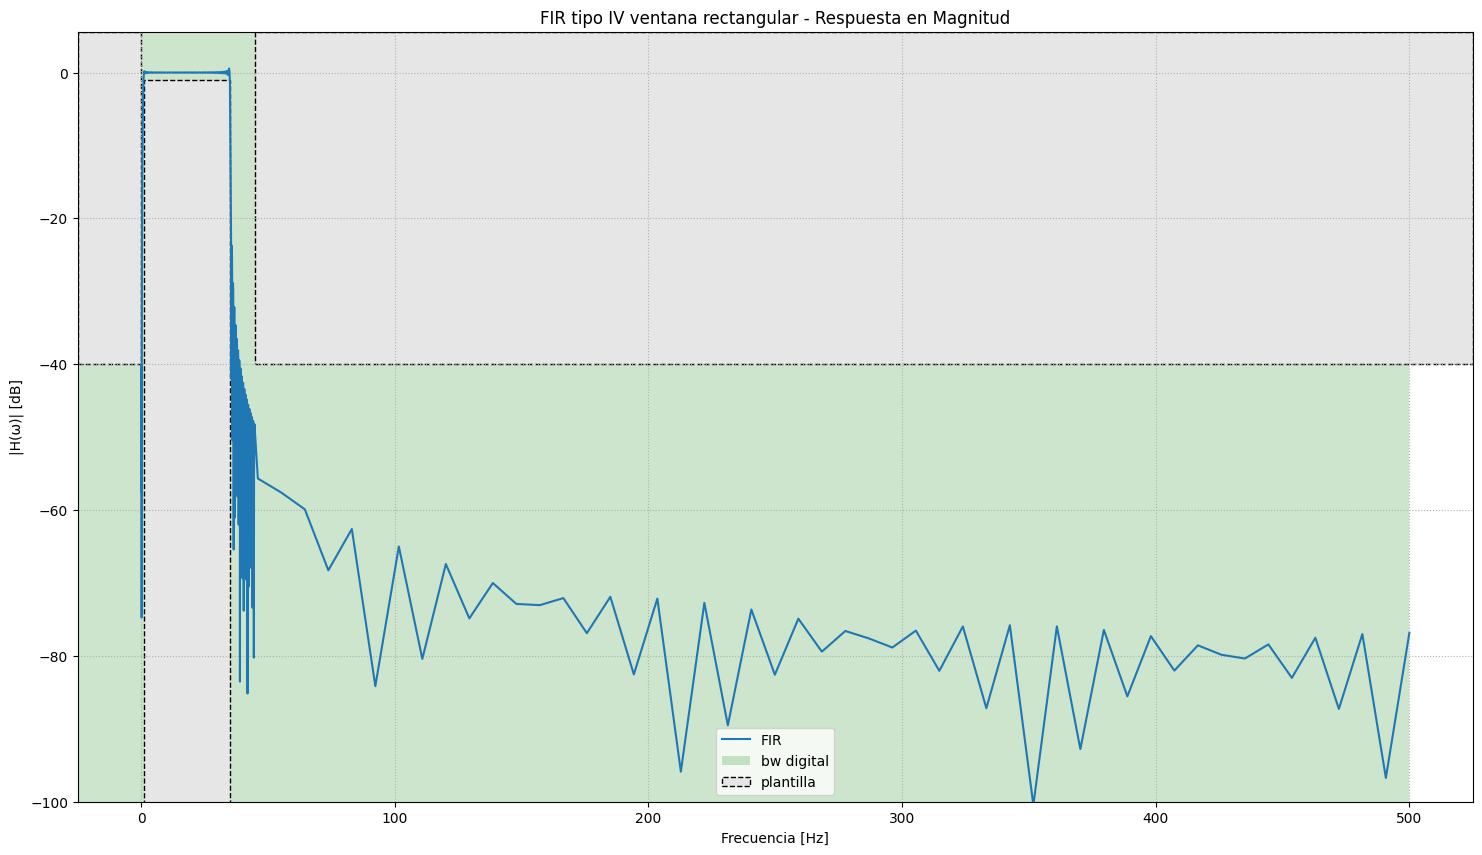

<Figure size 640x480 with 0 Axes>

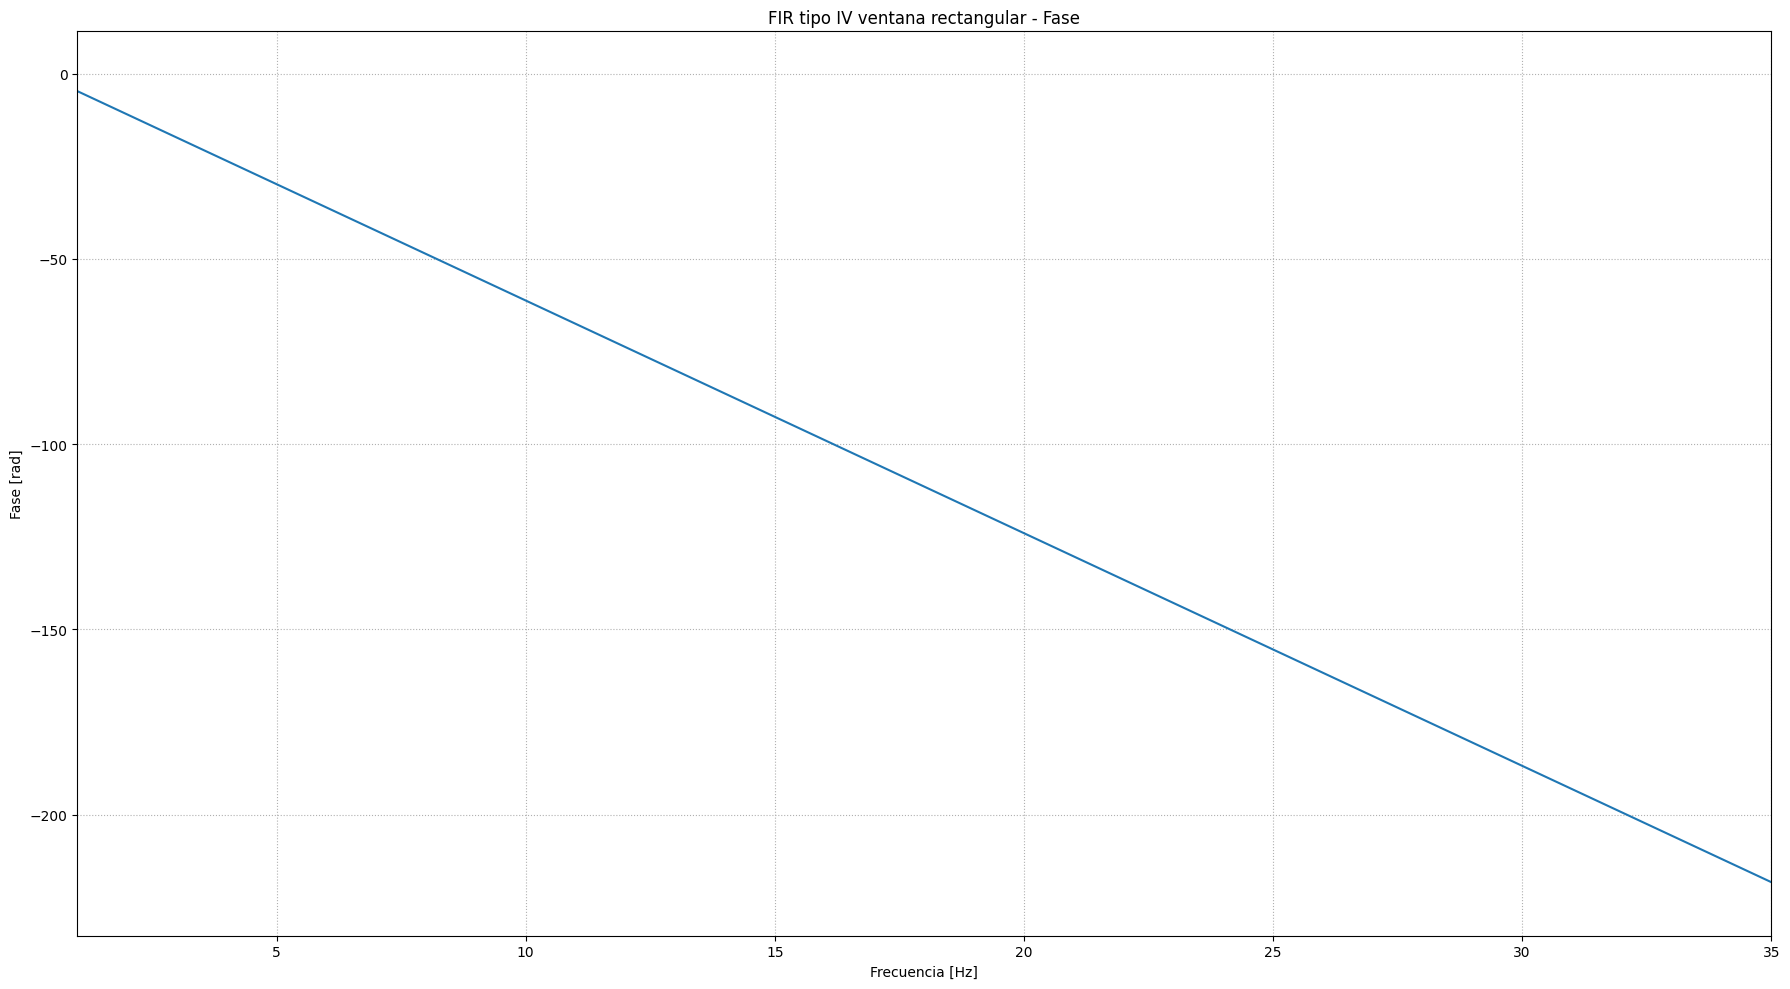

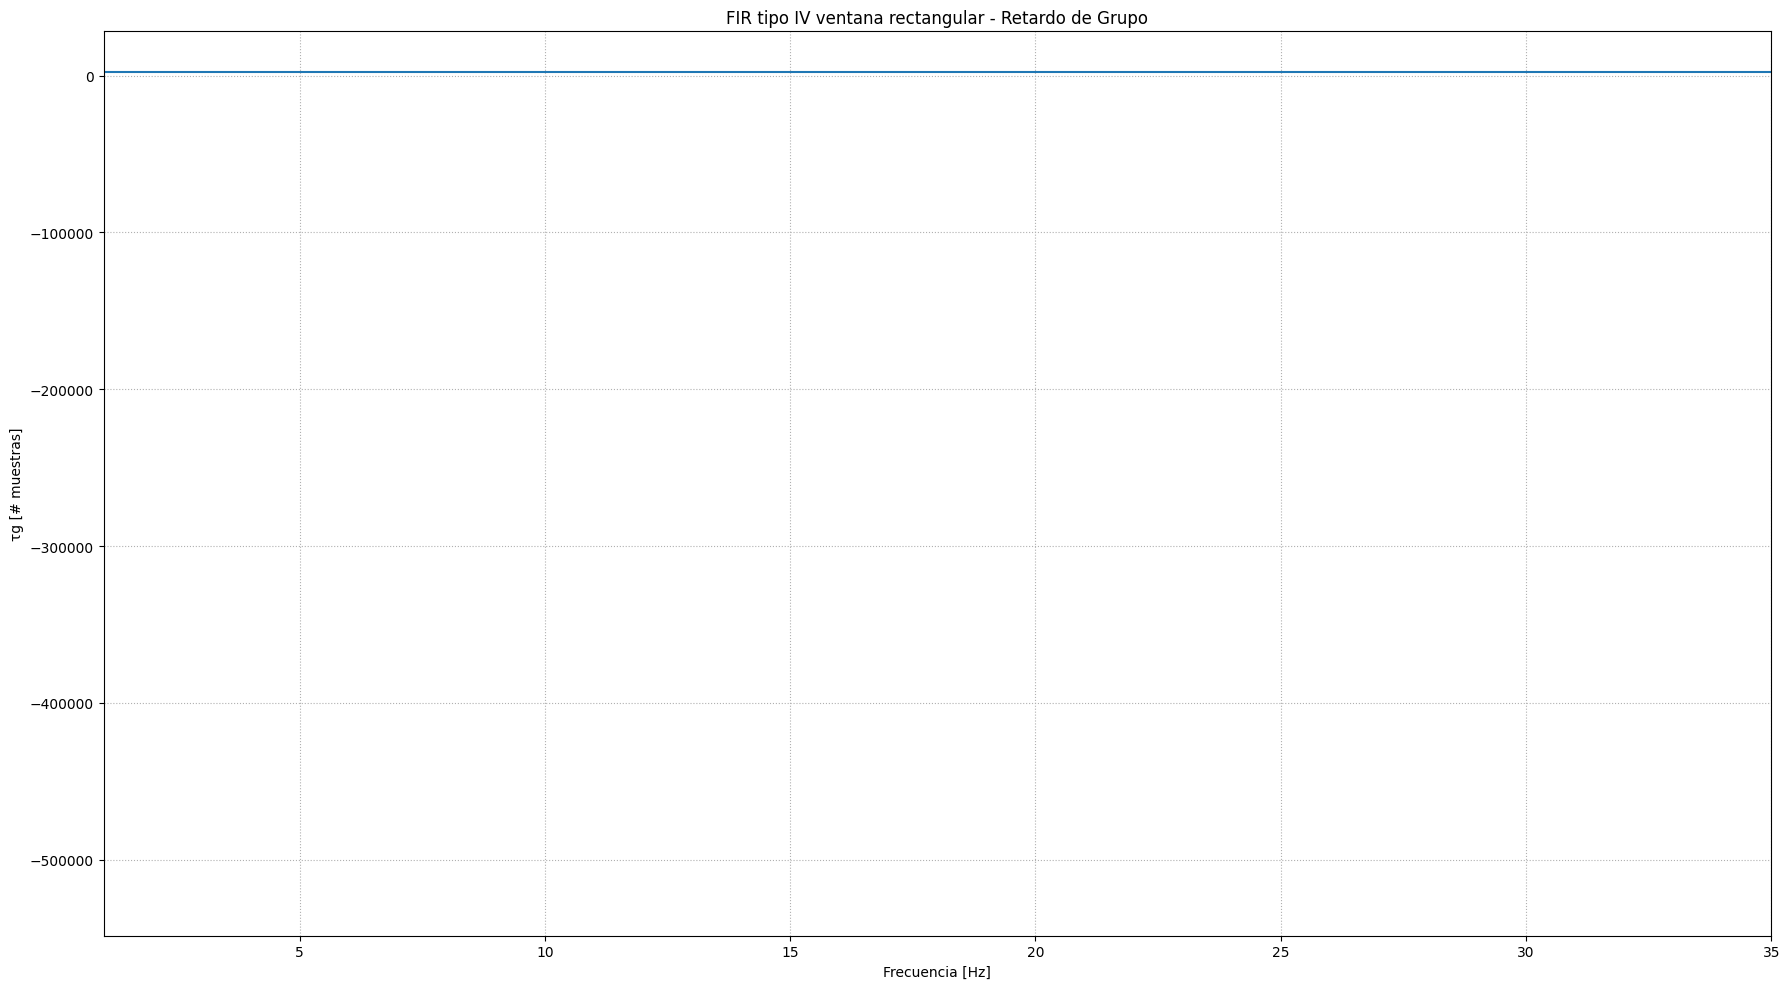

In [93]:
# Respuesta en frecuencia
w_fir_ant, h_fir_ant = sig.freqz(fir_win_ant, worN = ww, fs = fs)
fase_fir_ant = np.unwrap(np.angle(h_fir_ant))
gd_fir_ant = -np.diff(fase_fir_ant) / np.diff(w_fir_ant/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant, 20*np.log10(abs(h_fir_ant)), label="FIR")
plt.title('FIR tipo IV ventana rectangular - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant, fase_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(w_fir_ant[1:], gd_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(1, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

### *FIR tipo III por método de cuadrados mínimos*

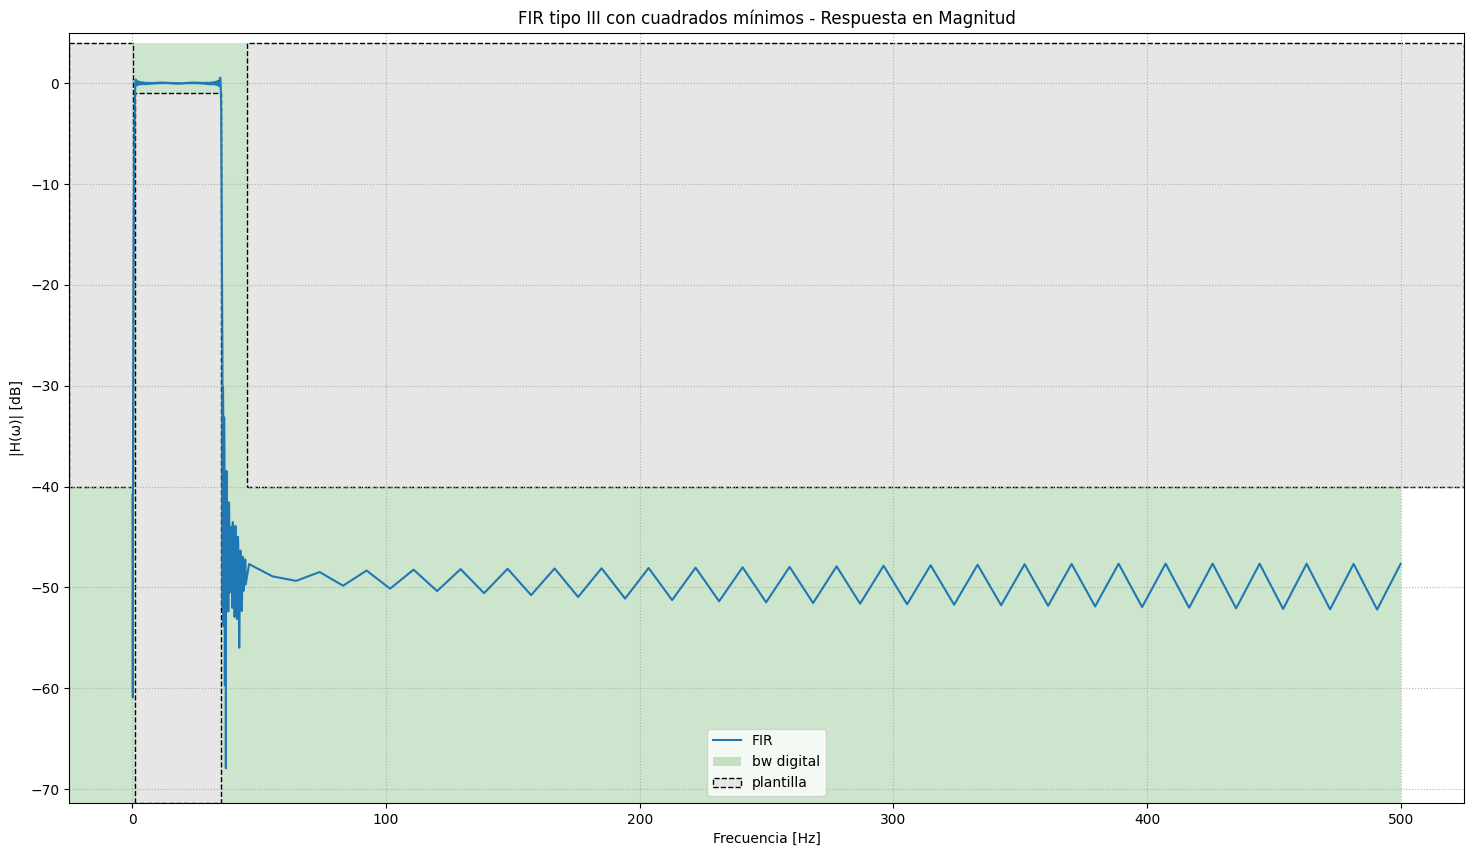

<Figure size 640x480 with 0 Axes>

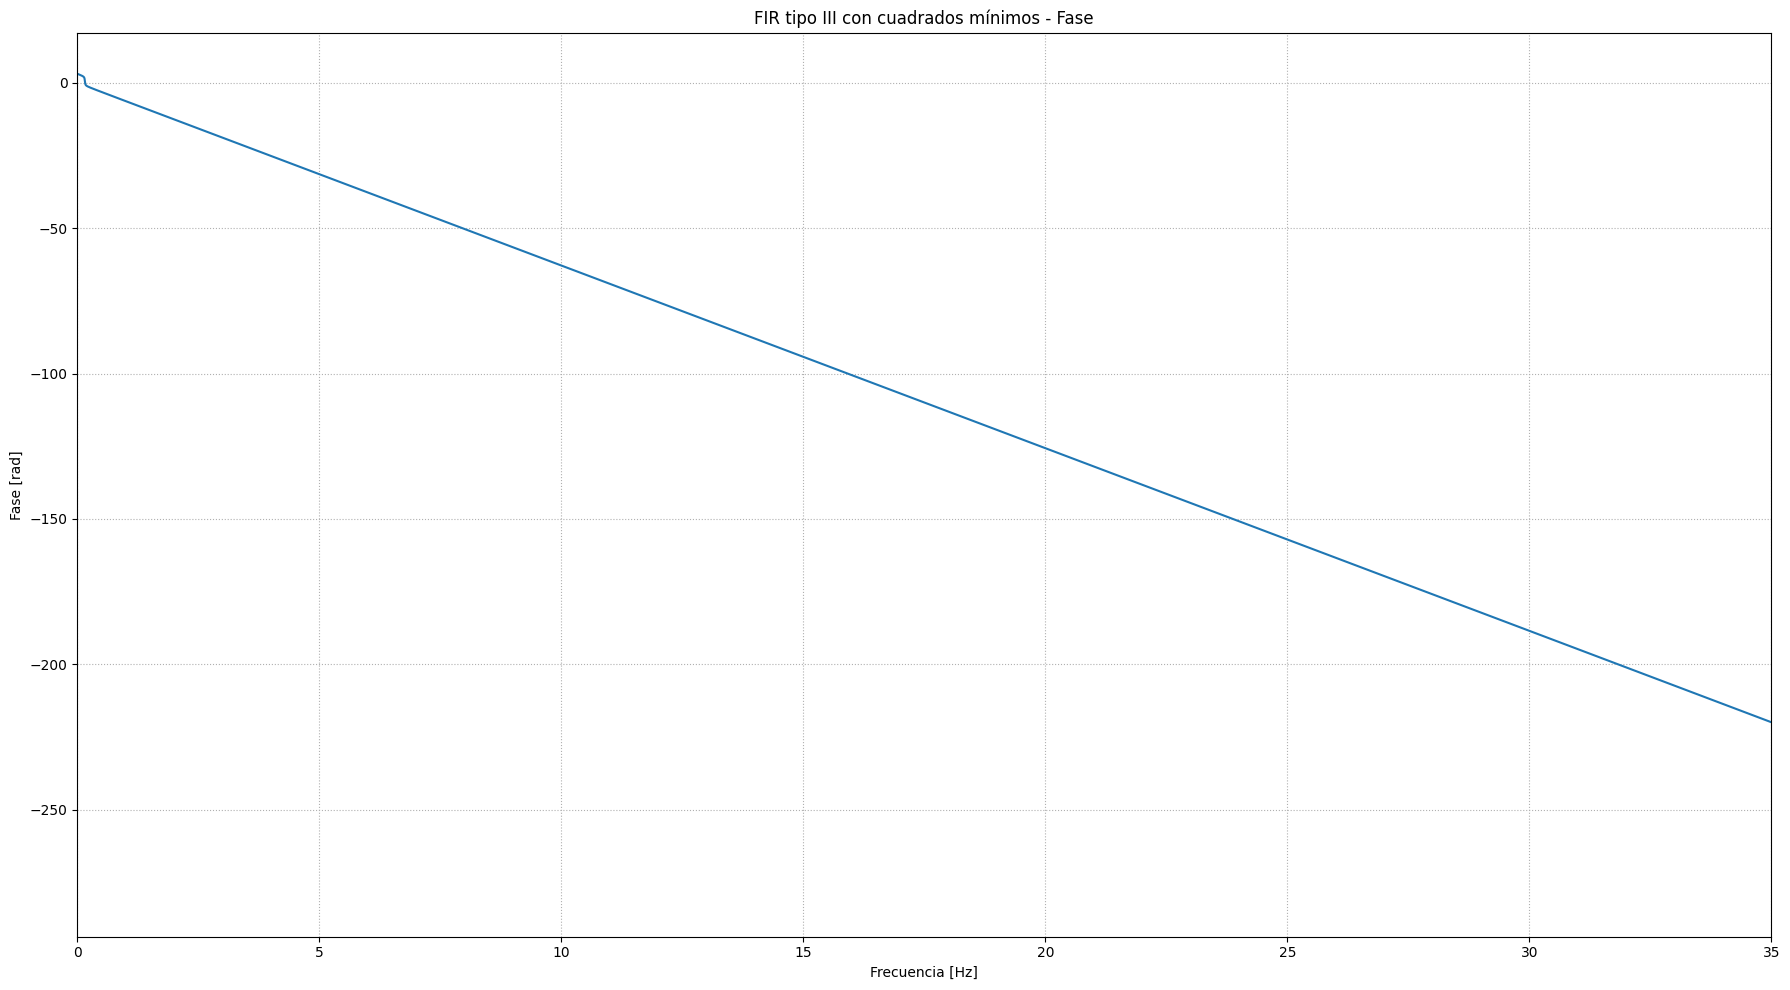

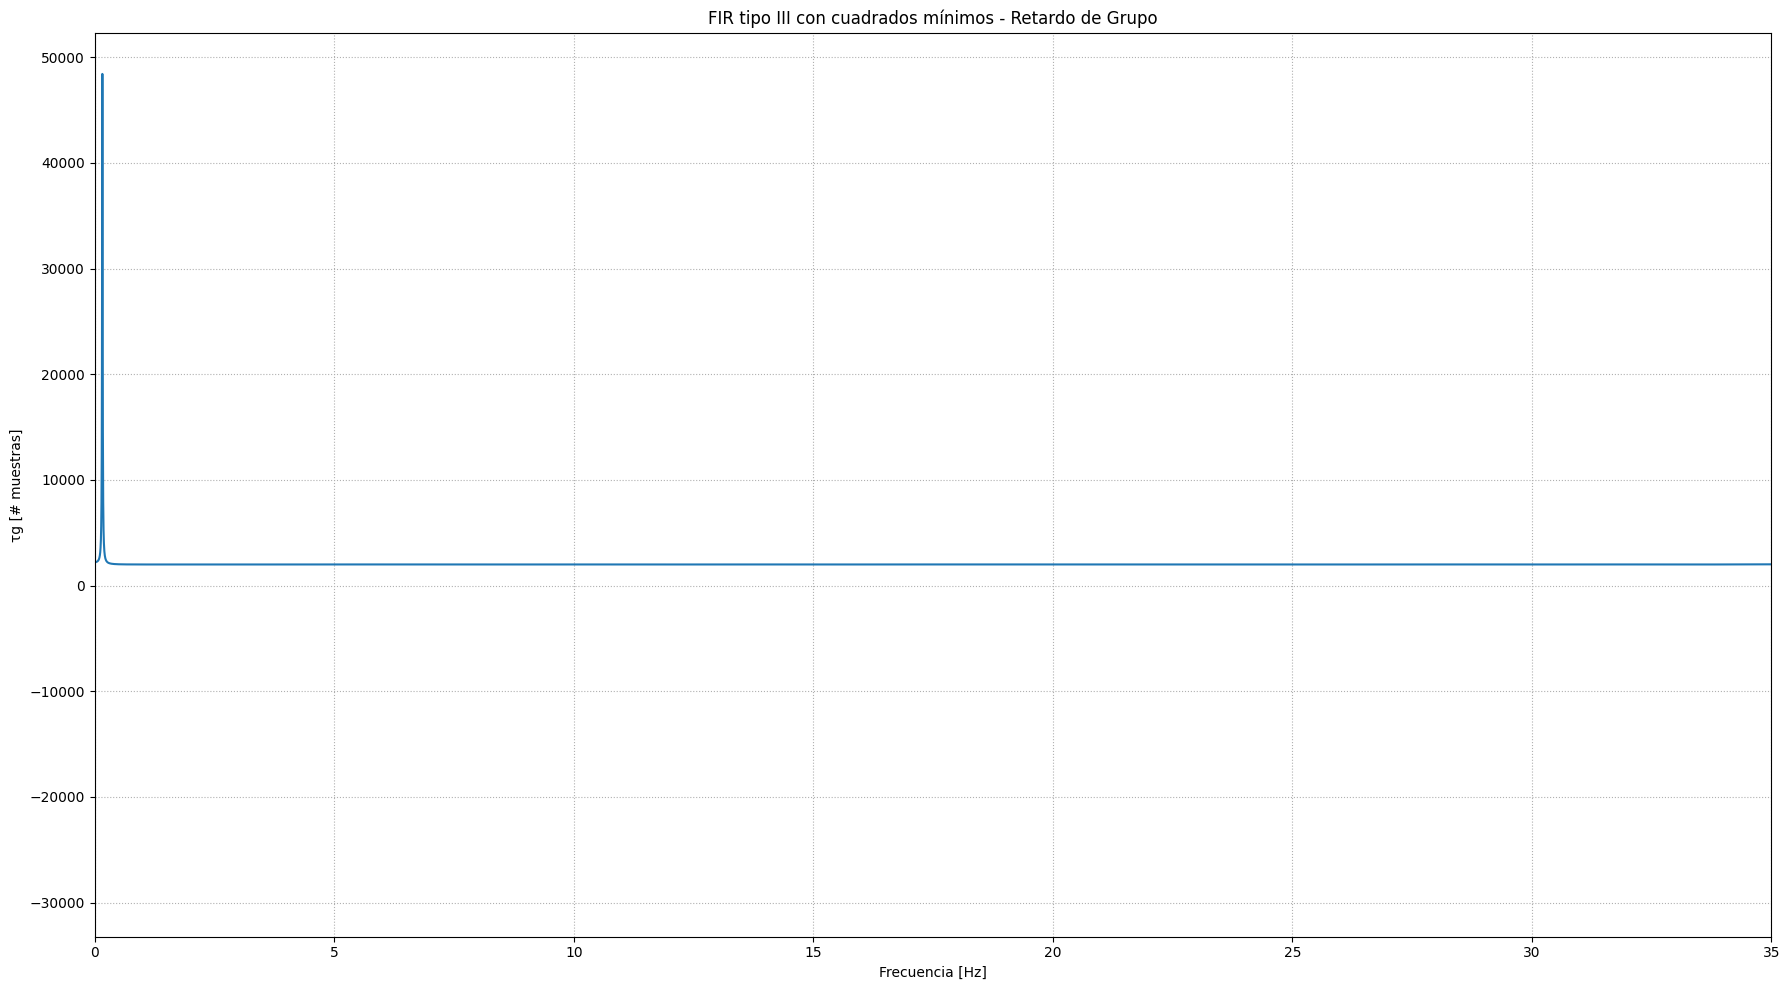

In [94]:
# Respuesta en frecuencia FIR antisimetrico 
ls_fir_ant, h_fir_ls_ant = sig.freqz(fir_antisym, worN = ww, fs = fs)
fase_fir_ls_ant = np.unwrap(np.angle(h_fir_ls_ant))
gd_fir_ls_ant = -np.diff(fase_fir_ls_ant) / np.diff(ls_fir_ant/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant, 20*np.log10(abs(h_fir_ls_ant)), label="FIR")
plt.title('FIR tipo III con cuadrados mínimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
plt.grid(True, which='both', ls=':')
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.tight_layout()
plt.show()

# FASE
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant, fase_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# RETARDO
plt.figure(figsize=(18,10))
plt.plot(ls_fir_ant[1:], gd_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

## *Aplicación de los filtros al ECG*

Posteriormente, los filtros *FIR* fueron aplicados a la señal *ECG* utilizando la función `filtfilt()`. 

In [95]:
# Procesar el ECG
import scipy.io as sio

fs_ecg = 1000 # Hz

# ECG con ruido 
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']. flatten()

ecg_firwin = sig.filtfilt(fir_win_ant, 1., ecg_one_lead)
ecg_firls = sig.filtfilt(fir_antisym, 1., ecg_one_lead)

## *Evaluación del desempeño*

Finalmente, se analizaron las mismas regiones de interés utilizadas para los filtros *IIR* con el fin de comparar los resultados obtenidos. 

Se verificó la capacidad de los filtros para atenuar las componentes interferentes y, simultáneamente, preservar la morfología de los complejos cardíacos en las zonas donde la señal presentaba una calidad adecuada. 

### *Regiones de interés sin ruido*

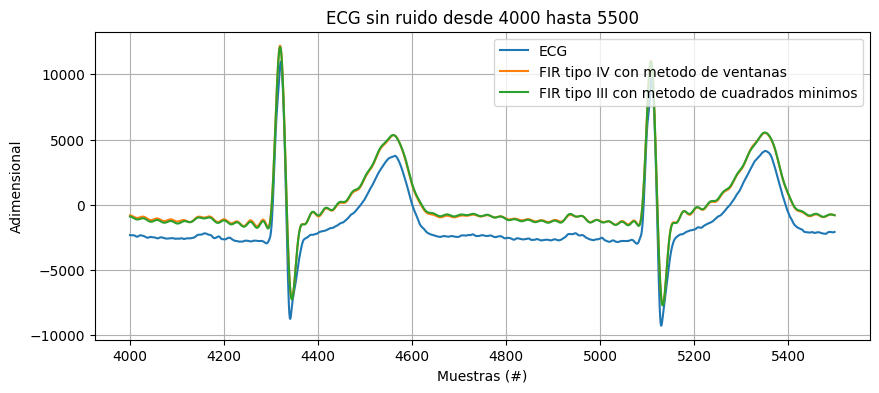

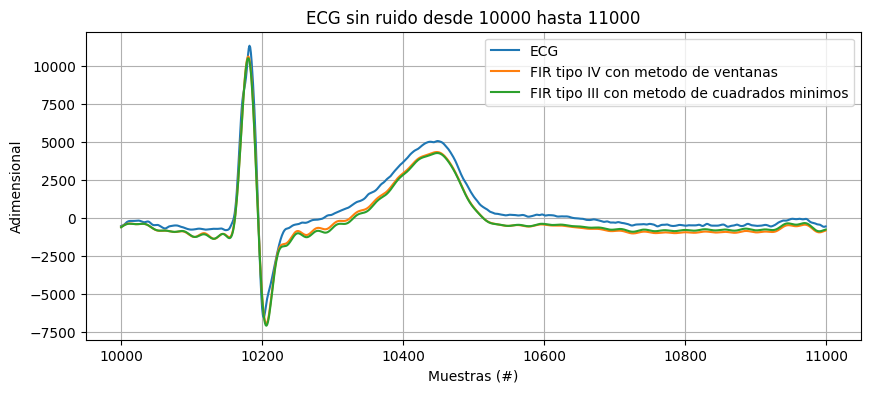

In [96]:
# GRAFICOS — ZONAS SIN RUIDO

regiones_sin_ruido = [
    [4000, 5500],
    [10000, 11000]
]

for r in regiones_sin_ruido:
    a,b = r
    t = np.arange(a,b)

    plt.figure(figsize=(10,4))
    plt.plot(t, ecg_one_lead[t], label="ECG")
    plt.plot(t, ecg_firwin[t], label="FIR tipo IV con metodo de ventanas")
    plt.plot(t, ecg_firls[t], label="FIR tipo III con metodo de cuadrados minimos")
    plt.title('ECG sin ruido desde ' + str(r[0]) + ' hasta ' + str(r[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.legend()
    plt.grid()

### *Regiones de interés con ruido*

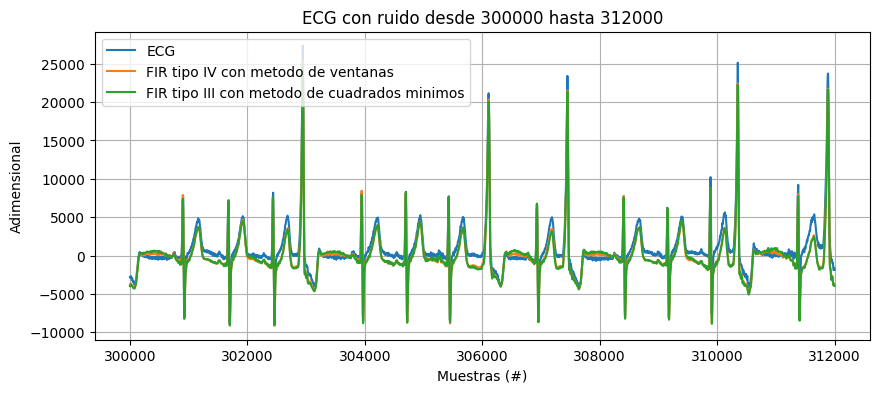

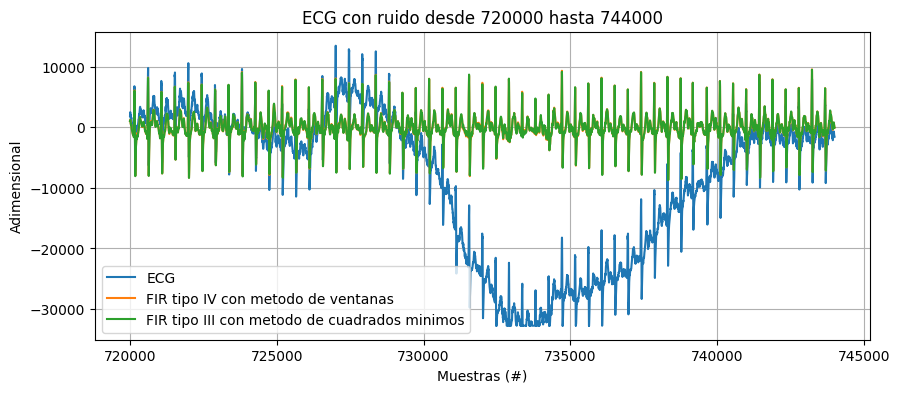

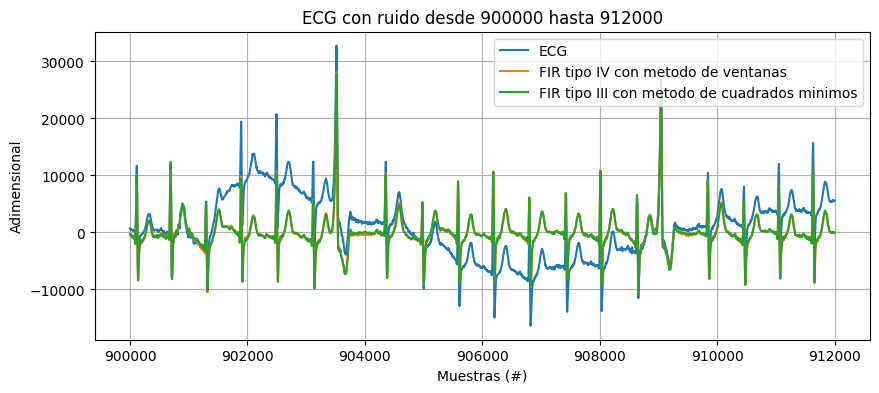

In [97]:
# GRAFICOS — ZONAS CON RUIDO

regiones_ruidosas = [
    (np.array([5, 5.2])*60*fs).astype(int),
    (np.array([12, 12.4])*60*fs).astype(int),
    (np.array([15, 15.2])*60*fs).astype(int)
]

for r in regiones_ruidosas:
    a,b = r
    t = np.arange(a,b)

    plt.figure(figsize=(10,4))
    plt.plot(t, ecg_one_lead[t], label="ECG")
    plt.plot(t, ecg_firwin[t], label="FIR tipo IV con metodo de ventanas")
    plt.plot(t, ecg_firls[t], label="FIR tipo III con metodo de cuadrados minimos")
    plt.title('ECG con ruido desde ' + str(r[0]) + ' hasta ' + str(r[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.legend()
    plt.grid()

# <u>**Conclusiones**</u>

En el presente trabajo se diseñaron e implementaron distintos filtros digitales con el objetivo de reducir las principales fuentes de contaminación presentes en una señal electrocardiográfica real, incluyendo el movimiento de la línea de base, el ruido muscular y las interferencias de alta frecuencia asociadas al movimiento de los electrodos. A partir del análisis previo del contenido espectral del *ECG*, fue posible establecer una plantilla de diseño adecuada para preservar la información fisiológica de interés y atenuar las componentes no deseadas. 

En primer lugar, se analizaron diferentes aproximaciones *IIR*, utilizando filtros Butterworth, Chebyshev tipo II y Cauer. Se verificó que las tres alternativas cumplen con las especificaciones de diseño planteadas, aunque presentan diferencias en su comportamiento. El filtro Butterworth ($taps_{butter} = 40$) mostró una respuesta más suave y de máxima planicidad en la banda de paso, mientras que el filtro Chebyshev tipo II ($taps_{cheby2} = 16$) permitió obtener una mayor selectividad gracias a su comportamiento equiripple en la banda de rechazo. Por su parte, el filtro Cauer presentó la transición más abrupta entre bandas y logró satisfacer la plantilla utilizando un orden menor ($taps_{cauer} = 10$). 

El análisis de la fase y del retardo de grupo permitió observar que los filtros *IIR* introducen distorsiones temporales debido a su comportamiento de fase no lineal. Por este motivo, la implementación mediante filtro bidireccional (`sosfiltfilt()`) resultó particularmente conveniente, ya que permitió eliminar el retardo de fase y preservar adecuadamente la sincronización temporal de la señal *ECG*. 

Posteriormente, se diseñaron filtros *FIR* mediante los métodos de ventanas y cuadrados mínimos. Debido a las exigencias de la plantilla original, fue necesario emplear una plantilla auxiliar más restrictiva durante el diseño ("plantilla hack"), logrando finalmente obtener filtros que cumplieran las especificaciones requeridas. Entre las configuraciones analizadas, los filtros antisimétricos fueron los que presentaron los mejores resultados, permitiendo satisfacer la plantilla y mantener las características deseadas de fase lineal. 

A diferencia de los filtros *IIR*, los filtros *FIR* presentaron una fase prácticamente lineal y un retardo de grupo constante dentro de la banda de paso. Estas propiedades son especialmente importantes en aplicaciones biomédicas, ya que minimizan la distorsión temporal y contribuyen a preservar la morfología de las ondas P, QRS y T. Sin embargo, para alcanzar prestaciones comparables a las de los filtros *IIR* fue necesario utilizar órdenes considerablemente mayores, incrementando la complejidad computacional del diseño. 

Finalmente, el análisis de distintas regiones de la señal permitió comprobar que los filtros diseñados reducen significativamente las interferencias presentes sin introducir modificaciones apreciables en las zonas donde la señal se encontraba libre de ruido. En consecuencia, pude concluir que tanto los filtros *FIR* como los *IIR* constituyen herramientas adecuadas para el procesamiento de señales *ECG*. Mientras que los filtros *IIR* permiten alcanzar las especificaciones con órdenes más bajos y menor costo computacional, los filtros *FIR* ofrecen una mejor preservación de la información temporal gracias a su comportamiento de fase lineal. La elección entre ambas alternativas dependerá, por lo tanto, de los requerimientos específicos de la aplicación y del compromiso deseado entre complejidad y fidelidad de la señal procesada. 